Задание 1:

В папке с данными (data) расположен датасет bbc , который содержит 5 классов новостных статей (business, entertainment, politics, sport, tech). Вам необходимо реализовать следующее:

Обучить любой (на ваш выбор) алгоритм классификации из классических алгоритмов машинного обучения (не нейронная сеть!) и измерить метрику качества работы модели (не забываем также проверять качество на инференсе).
Дообучить модель DistillBert для многоклассовой классификации и проверить также качество работы алгоритма (н забываем проверять качество на инференсе). Похожий код был продемонстрирован на лекции, думаем головой, не копипастите, есть нюансы в данной задаче.
Оформить оба решения в пайплайны. Отдаем новости – получаем метку класса и вероятность. Соскрапить или собрать вручную по пять свежих новостей с ресурса (https://www.bbc.com/news - ссылки на новости прикрепить в ноутбуке) для каждого из классов и прогнать на них пайплайны.  Получить результаты инференса пайплайнов, и оценить какое из решений лучше.

In [1]:
import torch
import os
import transformers
import numpy as np
import sys
import matplotlib.pyplot as plt
import warnings
import pandas as pd
import time
import logging
from sklearn.base import BaseEstimator
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score
torch.backends.cudnn.deterministic = True
warnings.filterwarnings("ignore")

In [2]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("DEVICE: ", DEVICE)

DEVICE:  cpu


In [3]:
DATA_DIR = "./data/bbc/"

class BbcDataset:
    def __init__(self, data_dir=DATA_DIR):
        self.data_dir = data_dir
        self.documents = [
            os.path.join(path, name)
            for path, _, files in os.walk(self.data_dir)
            for name in files
        ]
        self.dataframe = self.get_pandas_alike_dataset()

    def get_dataset(self):
        """Загружает все документы и их категории"""
        data = []
        for file in self.documents:
            label = os.path.basename(os.path.dirname(file))
            try:
                with open(file, "r", encoding="utf-8") as f:
                    content = f.read().strip()
                data.append((content, label))
            except Exception as e:
                print(f"Ошибка чтения файла {file}: {e}")
        return data

    def get_pandas_alike_dataset(self):
        """Возвращает DataFrame с текстами и метками"""
        data = self.get_dataset()
        return pd.DataFrame(data, columns=["text", "label"])

In [4]:
bbc_dataset = BbcDataset()
df = bbc_dataset.get_pandas_alike_dataset()

In [5]:
# избавимся от дупликатов новостей
df = df.drop_duplicates(subset=['text'])

In [6]:
# закодируем метки классов
le = LabelEncoder()
df['label'] = le.fit_transform(df['label'])

In [7]:
X = df.text
y = df.label

In [8]:
from sklearn.model_selection import train_test_split

# 85% данных уходят в трейн
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=42
)

# 7.5% и 7.5% уходят на валидацию и тест
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

train_texts = X_train.values
train_labels = y_train.values

valid_texts = X_val.values
valid_labels = y_val.values

test_texts = X_test.values
test_labels = y_test.values

In [9]:
X_train.shape, X_test.shape, X_val.shape

((1803,), (160,), (159,))

### Оформим пайплайн для классического алгоритма классификации

In [10]:
from nltk.tokenize import RegexpTokenizer
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords
import spacy

# загружаем spaCy
nlp = spacy.load("en_core_web_sm")

# дополнительные стоп-слова 
additional_stop_words = {
    'say', 'go', 'get', 'would', 'make', 'could', 'can', 'may', 
    'take', 'come', 'give', 'look', 'find', 'use', 'tell', 'ask', 
    'work', 'seem', 'feel', 'try', 'leave', 'call', 'good', 'well', 
    'think', 'also', 'even', 'know', 'want', 'year', 'time', 'new'
}

class TextPreparator(BaseEstimator):
    def __init__(self):
        # настраиваем токенизатор на латинские буквы и цифры
        # токенизатор проигнорирует \n, \r, \t, пунктуацию и лишние пробелы
        tokenizer = RegexpTokenizer(r'[a-z0-9]+')
        # приводим к нижнему регистру, избавляемся от дефисов (нормализируем) и токенизируем
        tokenize_func = lambda text: [
            word for word in tokenizer.tokenize(text.lower().replace('-', ''))
        ]
        
        # проводим лемматизацию 
        lemmatize_func = lambda tokens: [t.lemma_ for t in nlp(" ".join(tokens))] if tokens else []
        
        # проводим очистку от стоп-слов 
        stop_words = set(stopwords.words('english')).union(additional_stop_words)
        stop_words_filter_func = lambda tokens: [
            word for word in tokens if word not in stop_words
        ]

        # векторизуем для NumPy массива
        self.v_tokenize = np.vectorize(tokenize_func, otypes=[object])
        self.v_lemmatize = np.vectorize(lemmatize_func, otypes=[object])
        self.v_remove_stop_words = np.vectorize(stop_words_filter_func, otypes=[object])

    def fit(self, X, y):
        self.is_fitted_ = True
        return self

    def transform(self, X):
        # шаг 1: нормализация, токенизация и фильтрация по стоп-словам
        tokens_result = self.v_tokenize(X)
        # шаг 2: лемматизация
        lemmatized_result = self.v_lemmatize(tokens_result)
        # шаг 3: удаление стоп-слов
        final_result = self.v_remove_stop_words(lemmatized_result)
        return final_result        

In [11]:
from gensim.models import Word2Vec 
from collections import defaultdict

class WordVectorizer(BaseEstimator):
    def __init__(self, vector_size = 200):
        self.vector_size = vector_size
        self.tfidf_word_to_weight = None

    def fit(self, X, y):
        # обучаем word2vec модель для получения векторного представления токенов
        word_to_vec = Word2Vec(vector_size = self.vector_size, window=50, min_count=5, workers=-1, sg=1)
        word_to_vec.build_vocab(X)
        word_to_vec.train(X, total_examples = word_to_vec.corpus_count, epochs=20)
        # получаем словарь слово(токен) : вектор
        self.word_to_vec_dict = dict(zip(word_to_vec.wv.index_to_key, word_to_vec.wv.vectors))
        self.dim = len(self.word_to_vec_dict.popitem()[1])

        # cоздаем весовую модель для слов всего корпуса
        tfidf = TfidfVectorizer(analyzer = lambda x: x)
        tfidf.fit(X)
        max_idf = max(tfidf.idf_)
        self.tfidf_word_to_weight = defaultdict(
            lambda: max_idf,
            [(w, tfidf.idf_[i]) for w, i in tfidf.vocabulary_.items()])
        
        self.is_fitted_ = True
        return self

    def transform(self, X):
        # вычисляется среднее взвешенное значение векторов всех слов каждого текста
        return np.array([
            np.mean([self.word_to_vec_dict[word] * self.tfidf_word_to_weight[word] \
                     for word in word_list if word in self.word_to_vec_dict] or [np.zeros(self.dim)], axis=0)
            for word_list in X
        ])

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

classic_classifier_pipeline = Pipeline([
    ("preparator", TextPreparator()), 
    ("vectorizer", WordVectorizer()),
    ('scaler', StandardScaler()), 
    ("classifier", LogisticRegression(C=0.005, solver='lbfgs', max_iter=1000))
])

start_time = time.time()
classic_classifier_pipeline.fit(train_texts, train_labels)
print(f'Время обучения для классификатора логистической регрессии: {(time.time() - start_time)/60:.2f} min')

Время обучения для классификатора логистической регрессии: 0.86 min


In [13]:
test_preds = classic_classifier_pipeline.predict(test_texts)
print("Accuracy для тестовых данных: {0:6.2f}".format(accuracy_score(test_labels, test_preds)))

Accuracy для тестовых данных:   0.81


### Оформим пайплайн для DistillBert алгоритма классификации

In [14]:
class IMDbDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

In [15]:
class DistillbertTokenizer(BaseEstimator):
    def __init__(self, truncation = True, padding = True, num_labels = 5):
        self.truncation = truncation
        self.padding = padding
        self.num_labels = num_labels
        self.tokenizer = transformers.DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased', num_labels = self.num_labels)

    def fit(self, X, y):
        self.is_fitted_ = True
        return self

    def transform(self, X):
        return self.tokenizer(list(X), truncation = self.truncation, padding = self.padding).to(DEVICE)

In [16]:
import evaluate
from transformers import DistilBertConfig, Trainer, TrainingArguments

metric = evaluate.load("accuracy")

class DistillbertClassifier(BaseEstimator):
    def __init__(self, num_labels = 5, lr = 5e-5):
        self.num_labels = num_labels
        self.lr = lr
        config = DistilBertConfig.from_pretrained(
            'distilbert-base-uncased', 
            dropout=0.5, 
            attention_dropout=0.5,
            num_labels = self.num_labels
        )
        self.classifier = transformers.DistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', config=config)
        self.classifier.to(DEVICE)
        self.classifier.train()
        self.optim = torch.optim.AdamW(
            self.classifier.parameters(), 
            lr = self.lr,
            weight_decay=0.01
        )

    def fit(self, X, y, eval_set=None):
        # Обучение через Trainer
        train_dataset = IMDbDataset(X, y)

        valid_dataset = None
        # если переданы данные для валидации, создаем valid_dataset
        if eval_set is not None:
            X_val, y_val = eval_set
            valid_dataset = IMDbDataset(X_val, y_val)
        
        training_args = TrainingArguments(
            output_dir='./output/task_1/distilbert/results',
            num_train_epochs=1,
            per_device_train_batch_size=16,
            per_device_eval_batch_size=16,
            logging_strategy = "steps",
            logging_steps = 20,
            eval_strategy = "steps",
            eval_steps = 20
        )
        
        trainer = Trainer(
            model=self.classifier,
            compute_metrics=compute_metrics,
            args=training_args,
            train_dataset=train_dataset,
            eval_dataset=valid_dataset,
            optimizers=(self.optim, None)
        )
        
        self.classifier.train()
        self.classifier.to(DEVICE)
        start_time = time.time()
        trainer.train()
        print(f'Время обучения для DistillbertClassifier: {(time.time() - start_time)/60:.2f} min')
        
        self.is_fitted_ = True
        return self
    
    
    def predict(self, X):
        self.classifier.eval()
        self.classifier.to(DEVICE)
        
        with torch.no_grad():
            inputs = {k: torch.tensor(v).to(DEVICE) for k, v in X.items()}
            outputs = self.classifier(**inputs)
            
        # извлекаем логиты 
        return outputs.logits

In [17]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred 
    predictions = np.argmax(logits, axis=-1)
    return metric.compute(
               predictions=predictions, references=labels)

In [18]:
from sklearn.pipeline import Pipeline
logging.getLogger("huggingface_hub").setLevel(logging.ERROR)
transformers.logging.set_verbosity_error()

distillbert_tokenizer = DistillbertTokenizer()
distillbert_classifier_pipeline = Pipeline([("tokenizer", distillbert_tokenizer), ("classifier", DistillbertClassifier())])

distillbert_classifier_pipeline.fit(
    train_texts, train_labels,
    classifier__eval_set=(distillbert_tokenizer.transform(valid_texts), valid_labels)
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

{'loss': '1.422', 'grad_norm': '3.79', 'learning_rate': '4.159e-05', 'epoch': '0.177'}
{'eval_loss': '1.135', 'eval_accuracy': '0.8742', 'eval_runtime': '30.05', 'eval_samples_per_second': '5.291', 'eval_steps_per_second': '0.333', 'epoch': '0.177'}
{'loss': '0.7416', 'grad_norm': '3.16', 'learning_rate': '3.274e-05', 'epoch': '0.354'}
{'eval_loss': '0.5488', 'eval_accuracy': '0.9182', 'eval_runtime': '30.17', 'eval_samples_per_second': '5.271', 'eval_steps_per_second': '0.331', 'epoch': '0.354'}
{'loss': '0.3569', 'grad_norm': '1.973', 'learning_rate': '2.389e-05', 'epoch': '0.531'}
{'eval_loss': '0.3247', 'eval_accuracy': '0.9371', 'eval_runtime': '30.08', 'eval_samples_per_second': '5.286', 'eval_steps_per_second': '0.332', 'epoch': '0.531'}
{'loss': '0.2351', 'grad_norm': '14.87', 'learning_rate': '1.504e-05', 'epoch': '0.708'}
{'eval_loss': '0.2294', 'eval_accuracy': '0.9434', 'eval_runtime': '29.82', 'eval_samples_per_second': '5.333', 'eval_steps_per_second': '0.335', 'epoch': '

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'train_runtime': '1778', 'train_samples_per_second': '1.014', 'train_steps_per_second': '0.064', 'train_loss': '0.5426', 'epoch': '1'}
Время обучения для DistillbertClassifier: 29.64 min


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tokenizer', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,truncation,True
,padding,True
,num_labels,5
,num_labels,5
,lr,5e-05


In [19]:
test_preds_logits = distillbert_classifier_pipeline.predict(test_texts)
test_preds = torch.argmax(test_preds_logits, 1)
print("Accuracy для тестовых данных: {0:6.2f}".format(accuracy_score(test_labels, test_preds)))

Accuracy для тестовых данных:   0.97


## Оценка пайплайнов на свежих новостях

In [20]:
# ниже собраны свежие новости темы 'business'
label_business = "business"

news_1 = """Somalia says it is ready to begin its first offshore oil drilling operations, with a Turkish government-owned drilling ship expected to arrive off its coast on Friday.
The move follows the successful completion of seismic surveys last year by a Turkish research vessel.
In a post on X, Somalia's Petroleum Minister Dahir Shire described the move toward what would be the country's first offshore drilling as a "historic milestone in our offshore energy journey... A new chapter begins."
The foreign ministry said if the drilling were to be successful, it would unlock offshore oil reserves and support the country's economic recovery as a regional energy player.
The Turkish Petroleum Corporation's drilling ship, Çağrı Bey, is on its first international mission, heading into Somalia's territorial waters in the Arabian Sea.
It will carry out deep water drilling at sites identified by recent surveys that mapped the country's hydrocarbon potential.
"This signals Somalia's readiness to move into exploratory drilling, beginning with our most promising offshore prospects," Shire said.
He added that the country would ensure that the benefits of the oil drilling leads to national prosperity and improves the well-being of the people. 
Turkey and Somalia formalised their cooperation in 2024 through a production-sharing agreement.
On Monday, Somali Foreign Minister Ali Omar said the oil drilling campaign would reinforce Turkey's role as a "trusted long-term partner" in development.
Speaking on Saturday ahead of his planned travel to Somalia, Turkey's Energy Minister Alparslan Bayraktar said any discovery of oil or gas reserves would bring significant economic benefits to Somalia, East Africa and Turkey.
Ankara has been deepening its ties with Somalia and has invested in the country for more than a decade. It has also expanded its military presence there in recent years, where it already operates a major base built in 2017.
Researchers estimate the country holds billions of barrels of oil reserves, but exploration has been hampered by decades of conflict and political instability.
"""
news_1_reference = "https://www.bbc.com/news/articles/czrepkppnl1o"

news_2 = """When Greg Daily found himself homeless as a teenager, becoming a successful entrepreneur seemed an impossibility.
Aged 19 back in 2001, for six months he slept wherever he could in Minneapolis.
Short of money and struggling to find long-term employment, Daily couldn't afford to pay rent. So he had to ask friends and acquaintances if he could sleep on their sofas. On a few occasions he had to make do with a kitchen floor.
Business, though, was in his DNA.
"My grandfather sold brooms out of the back of a van," he says, recalling riding with him as young boy, as they would travel to sell cleaning equipment.
It taught Daily a lesson from a young age: "Businesses feed families."
Now 43, his life today is a million miles away from when he had to go to sleep hungry on a friend's sofa.
Daily is the founder and boss of a Denver-based digital marketing firms called Science in Advertising. Launched in 2019, it serves businesses from members of the Fortune 500 list of the largest US companies, down to "mom-and-pop shops" – small, family-owned retailers.
It helps all these clients manage their online advertising, enabling them to reach additional customers through platforms such as Google, Facebook and Instagram.
Despite the business lessons gained from his grandfather, Daily admits that his family life was "broken" when he was growing up in Denver.
"My parents were divorced when I was young… I was raised by a single mother."
When he was 10-years-old, his grandfather passed away, leaving his mother struggling to feed four children. To make money she'd sell clothes and jewellery, which Daily says was "a big part of what helped us survive".
As he reached adulthood, Daily moved around the US, spending six months in Texas with his grandmother, and six months with his father, before falling into couch surfing.
Travelling to Colorado for a construction job, Daily says the moment that changed his life was meeting his wife at a church. Twenty three years later they are still married.
Seeing that she was earning more money and working fewer hours, Daily decided to go back to college in 2008. He jokes that rather than it being "a romantic story" he realised that he needed qualifications to be able to earn more money.
After completing a journalism course at the Metropolitan State University of Denver he got a job on a local newspaper.
A few years later, with newspapers struggling in the face of smart phones and the internet, Daily moved to England to do a two-year creative writing diploma at Oxford University. "Here in the United States, print journalism was dying. I started thinking about how to write for businesses."
Upon his return to the US, his career in digital marketing for companies started.
When preparing to launch Science in Advertising, Daily says that he and his wife worked out they had around six to eight months of savings before they would run out of money. "It was terrifying," he says. "I was in tears."
He believed he could do the work, what frightened him was everything else.
"There were so many questions I didn't have answers to," he says. "What if it doesn't work? What if I fail? What if I can't provide?"
Rather than ignoring that fear, Daily says he built his business around it, making one phrase, central to how he operates - "failure is always an option".
It is something he now repeats to his team, particularly when they are facing a high-risk decision. "If you operate as though failure isn't possible, the ship is going to blow up," he explains.
Instead, he accepts that things can go wrong and if they do it is all about limiting the damage. "Assume failure is real," he says. "Now go look for it. Now try to find it. Now reduce the risk."
He adds that as long as you can still feed your kids, some level of short-term financial loss "doesn't matter".
The business has, however, been successful, and grown its client base. Daily says he's particularly proud to be helping small, family-owned businesses like his mother's and grandfather's.
"I love seeing them be successful because that's what I am. That's my family. That's the background I come from," he says.
US digital marketing expert Shama Hyder says that succeeding in the sector is "not easy". "The industry is saturated, competition is fierce, and with AI, shifting platforms, and changing consumer behaviour, marketing is about to get significantly harder."
She adds: "When someone like Greg builds a thriving agency in this space, that deserves real recognition."
"""
news_2_reference = "https://www.bbc.com/news/articles/cn08lx745ndoo"

news_3 = """In a hotel lobby on Hong Kong Island, a delivery robot pauses outside one of the lifts as the doors open, and a guest steps out. The robot waits, and then rolls neatly inside.
The move looks simple, but it isn't. To work in the busy hotel, owned by an international chain, the robot must navigate a building that won't slow down for it.
People are often getting in the way, and it must be able to take the lift to the correct floor, and then find the right room.
The company behind the robot, Yunji, is a mainland Chinese tech business that is aiming to use Hong Kong as a springboard for successful overseas expansion.
"We aim to make our product succeed in Hong Kong, and then expand outward," says the firm's vice-president, Xie Yunpeng.
Hong Kong is becoming increasingly important to such mainland Chinese tech companies as a place to raise money, test products with international clients, and build credibility for overseas expansion.
This matters because US and European nations have grown more wary of such Chinese companies. Dubbed "China risk" by some commentators, countries fear state-led espionage and excessive Chinese domination of their tech sectors.
For mainland Chinese tech firms it means they are finding access to capital, customers and trust harder to secure in some international markets. So, they are instead looking to Hong Kong in the first instance.
Last year, the number of mainland Chinese firms listing on the Hong Kong Stock Exchange increased to 76, up from 30 in 2024, an increase of 153%, according to a report by accountancy giant PricewaterhouseCoopers.
Invest Hong Kong, the investment promotion agency for the special administrative region, has also reported a rise in the number of mainland firms it has helped to set up or expand in the territory, with innovation and technology among the biggest sectors.
Xiaomeng Lu, a director at political consultancy Eurasia Group, says mainland Chinese tech firms are "shifting to Hong Kong" for their primary share listing as "geopolitical headwinds dampen their dreams" to float in New York.
"These days Hong Kong is their best hope to attract global investors and position themselves as a player not fully constrained by the boundary of the mainland market," she adds.
Meanwhile, Wendy Chang of the Mercator Institute for China Studies, a Germany-based think tank, says Hong Kong is "fashioning itself as a connector to the outside world for Chinese companies", with policies to speed up share flotations and help mainland firms set up operations in the city.
This increased focus on Hong Kong comes as the Chinese government in Beijing is aiming for the country to achieve more "technology self-reliance".
Significantly reducing its need for foreign hardware and software is now at the centre of its economic policy, especially regarding artificial intelligence and semiconductors.
This is a key focus of the country's new 15th Five-Year Plan, which sees technology not just as an economic priority but as a strategic one given tensions with the US.
In this context, the "strategic value of Hong Kong for high-tech Chinese companies" has increased, says Paul Triolo, a Washington-based partner of global business consultancy DGA Group.
Alicia Garcia-Herrero, chief economist for Asia-Pacific at French investment bank Natixis, says that Hong Kong offers mainland firms a place where they can show that they can meet international standards while building trust with global investors and clients.
For Yunji, that means proving its robots can operate in real-world international settings. The company, which builds its service robots for hotels, hospitals and factories, listed in Hong Kong in October of last year, as it sought to widen its investor base beyond the mainland.
MiningLamp Technology, a Chinese AI software company set up its operation in Hong Kong the same month. Its founder, Wu Minghui, calls Hong Kong a "data compliance transfer station", where mainland Chinese firms like his can test how to handle cross-border data flows and build compliance processes before moving into other markets.
But even if a mainland Chinese firm is successful in Hong Kong, it can still face barriers overseas.
Governments in the US and Europe have tightened national security reviews of Chinese investments and technology, citing concerns over data access and critical infrastructure. Some countries, like the US and UK have also moved to restrict or phase out Chinese suppliers from telecoms networks.
Western nations also have broader concerns about Chinese firms' governance and transparency. The Luckin Coffee scandal remains a cautionary tale for many international investors after the Chinese company admitted fabricating sales.
The revelation saw its shares being delisted from New York's Nasdaq stock market in 2020.
Meanwhile, Hong Kong is not as appealing to international companies and investors as it once was. Since mass pro-democracy protests in 2019, authorities have imposed a sweeping national security law and new local security legislation.
Dozens of activists, opposition politicians and journalists have been arrested or jailed under security or related laws. Beijing and Hong Kong officials say the measures were necessary to restore stability and order, but critics say this has sharply curtailed political freedoms.
And Triolo says that even with a Hong Kong base, many mainland companies remain bound by evolving rules set in Beijing, from cybersecurity and data controls, to requirements for public-facing AI.
"Hong Kong is not really a geopolitical shield [for such firms]", he says, adding that it "only partially mitigates" their risks.
"""
news_3_reference = "https://www.bbc.com/news/articles/c8d5v404m96o"

news_4 = """Air India and Air New Zealand announced they will cut flights and hike fares as jet fuel prices surge due to the US-Israeli war with Iran.
Many airlines around the world have had to take emergency measures to counter the rising cost of fuel, which typically makes up 20-40% of their operating costs.
Last week, the benchmark European jet fuel price hit an all-time high of $1,838 (£1,387) per tonne, compared with $831 before the war began.
Analysts warned that travellers should expect further ticket price rises and more cancelled flights as the conflict continues.
The Gulf is a major source of aviation fuel, accounting for about 50% of Europe's imports. The bulk of it comes through the Strait of Hormuz, which Iran has effectively closed in response to US and Israeli attacks.
The increase in jet fuel prices reflects the role Middle Eastern refineries play in supplies. The Al-Zour refinery in Kuwait alone provides roughly 10% of Europe's jet fuel imports, according to Energy Intelligence.
Air New Zealand's cancellations are expected to hit routes in and out of Auckland, Wellington and Christchurch, with flights to smaller airports unchanged.
The airline, which had already cut some flights last month, said on Tuesday the "vast majority" of customers affected by the cancellations were being offered alternative flights on the same day.
"Like airlines globally, we're experiencing jet fuel prices that are more than double what they would usually be" a spokesperson said.
Meanwhile, Air India said it would change the fuel surcharge on its domestic flights from a flat fee to one based on the distance of the flight.
It also increased its surcharges for international flights due to what it said was "one of the most challenging fuel cost environments that airlines globally have faced in recent years".
Many airlines in Asia have been trimming services and raising fares to cope with the situation. Major economies, including Japan and South Korea, have been particularly affected by the disruptions as they are heavily reliant on energy from the Middle East.
Last week, China Eastern Airlines said it was raising surcharges for domestic flights while Korean Air said it was moving into emergency management mode.
Airlines globally have also been taking action. United Airlines in the US and Scandinavia's SAS are among those to have cut flights and increased ticket prices.
Air France-KLM has said it will lift fares for long-haul journeys, while Cathay Pacific is raising its fuel surcharge.
British Airways owner IAG and EasyJet have been able to hold off on either measure so far as they are buying their fuel at a price fixed before the war began.
However, Ryanair Michael O'Leary told Sky News last week that jet fuel supplies could start to be disrupted in May if the conflict continued.
Analysts told the BBC that rising ticket fares and flight cancellations are likely to continue.
"Starting from an already tight market, the current lack of Middle East jet fuel exports is worsening the situation," said Mick Strautmann, an analyst at data firm Vortexa.
"Given global jet fuel exports are currently at their lowest point in four years, the same level of air travel demand will likely not be sustainable if disruptions persist, meaning airlines will likely have to increase prices further, and reduce the number of flights," he said.
He added that this will be "more and more likely" as peak summer travel season summer approaches for many parts of the world.
However, despite the tightness of supply, George Shaw, senior insight analyst at trade intellegnce firm Kpler said shortages were still a way off.
"Europe is not close to running out, as jet fuel is produced domestically and generally April should be manageable in terms of stocks," he said, but added that there may be "some localised issues" in May as the drop in imports is "more keenly felt".
"""
news_4_reference = "https://www.bbc.com/news/articles/c87w4x0n3j0o"

news_5 = """Global oil prices have fallen sharply and stock markets have jumped after the US and Iran agreed to a conditional two-week ceasefire deal that includes the reopening of the key Strait of Hormuz waterway.
The price of benchmark Brent crude fell by about 13% to $94.80 (£70.73) a barrel, while US-traded oil was more than 15% lower at $95.75.
But oil prices remain higher than before the conflict started on 28 February. At the time, it was trading at around $70 a barrel.
The cost of energy has jumped as oil and gas supplies from the Middle East have been severely disrupted after Iran threatened to attack ships trying to use the strait in retaliation to US and Israeli airstrikes.
Stock markets in Europe opened higher following sharp rises in Asia. London's FTSE 100 share index jumped by 2.53% in opening trade. In France, the Cac gained 4% while Germany's Dazx rose by nearly 5%.
Japan's Nikkei 225 gained 5% while South Korea's Kospi jumped nearly 6%. Hong Kong's Hang Seng was up 2.8%, while the ASX 200 in Australia gained 2.7%.
US stock market futures also pointed to a higher open for Wall Street.
Futures contracts are an agreement to buy an asset for a set price at a later point in time. In the case of US stock futures, they can indicate the direction of the market before it opens.
In a social media post on Tuesday evening, Trump said: "I agree to suspend the bombing and attack of Iran for a period of two weeks... subject to the Islamic Republic of Iran agreeing to the COMPLETE, IMMEDIATE, and SAFE OPENING of the Strait of Hormuz".
He had set a deadline for 20:00 EDT on Tuesday (00:00 GMT on Wednesday), threatening that "a whole civilisation will die tonight" if no deal was reached.
Iranian Foreign Minister Abbas Araghchi said on social media that Tehran will agree to a ceasefire "if attacks against Iran are halted", adding that safe passage through the Strait of Hormuz "will be possible".
Despite his threats, Trump was likely to be wary about letting energy prices "skyrocket" by escalating the conflict, said Xavier Smith from market research firm AlphaSense.
That could have led to a "self-inflicted economic wound" that few would risk, especially given the looming pressure of approval ratings on Trump's leadership, said Smith, a research director.
More oil tankers stranded near the strait may be able to pass through the waterway during the ceasefire, providing some relief for markets in the coming weeks, said analyst Saul Kavonic from financial services firm MST Marquee.
Despite the conflict, some ships have passed through the Strait of Hormuz, although far fewer than usual.
Asian countries - including India, Malaysia and the Philippines - have negotiated safe passage for their vessels in recent weeks.
China has also acknowledged that several of its ships have crossed the strait since the war began.
Meanwhile, a Malta-flagged container vessel owned by French company CMA CGM crossed the shipping route, media organisation BFM TV - which is owned by the shipping firm - confirmed on Friday.
And a Japanese ship carrying natural gas also made it out of the strait, shipping giant MOL confirmed.
Kavonic said that while a ceasefire is in place, it is still unlikely that energy production in the Middle East will fully resume until there is confidence of a lasting peace deal.
It could also take months for production to restart due to damage done to energy infrastructure in the region, he said.
Iran has targeted energy and industrial infrastructure across the oil-rich region in retaliation to the US-Israeli strikes.
It could take years to fix the damage and cost more than $25bn, according to research firm Rystad Energy.
Energy prices jumped in mid-March after strikes on Qatar's Ras Laffan industrial hub, which produces about a fifth of the world's liquefied natural gas.
The hub's owners said the attacks have reduced the country's export capacity by 17% and that it will take up to five years to repair the damage.
Asia has been hit particularly hard by the economic fallout of the Iran war as many countries are heavily reliant on energy from the Gulf.
Governments and companies across the region have announced measures in recent weeks to deal with high energy prices and fuel shortages.
On 24 March, the Philippines, which imports 98% of its oil from the Middle East, became the first country to declare a national energy emergency after petrol prices more than doubled.
Many airlines in the region have raised fares and cut flights in response to surging jet fuel prices.
Developing countries in Asia have been especially affected by the conflict as many do not have their own refineries or sufficient oil reserves, said Ichiro Kutani from Japan's Institute of Energy Economics.
"The ceasefire is good news for Asian countries. If it holds, oil prices will return to normal states, though this will take time."
"""
news_5_reference = "https://www.bbc.com/news/articles/c8r40y3rv75o"

In [21]:
# ниже собраны свежие новости темы 'politics'
label_politics = "politics"

news_6 = """The UK and its allies have agreed to explore using sanctions to pressure Iran into reopening the Strait of Hormuz, according to Foreign Secretary Yvette Cooper.
Representatives from more than 40 countries took part in a virtual summit on Thursday billed as the beginning of efforts to assemble a coalition capable of ensuring security in the Gulf shipping channel.
Cooper said Iran has been able to "hijack" the international shipping route to "hold the global economy hostage" following the talks, which the US was not involved in.
Iran has attacked several vessels in response to the war waged against it by the US and Israel, disrupting energy exports and sending global fuel prices soaring.
Cooper noted the focus of the talks was on diplomatic measures as opposed to military options, adding the countries want to use "every possible diplomatic, economic and coordinated measure" to reopen the Strait.
She said this includes increased pressure through the United Nations, exploring the possibility of sanctions to "bear down on Iran if the Strait remains closed" and working with the International Maritime Organisation to ensure the first stranded ships can get moving again.
The foreign secretary said: "Iran's closure of the Strait of Hormuz is a direct threat to global prosperity."
Cooper highlighted its importance in several areas, including trading routes for Gulf nations, energy exports to Asia and fertiliser supplies for farming in Africa.
She added: "Iran is trying to hold the global economy hostage in the Strait of Hormuz. They must not prevail.
"To that effect, partners today called for the immediate and unconditional reopening of the Strait and respect for the fundamental principles of freedom of navigation and the law of the sea."
US and Israel continue war against Iran - follow live
On Wednesday, US President Donald Trump said it was for other nations to "build up some delayed courage" and reopen the route.
Trump said allies "should have done it" earlier, adding: "Go to the Strait and just take it. Protect it. Use it for yourselves."
Washington has repeatedly accused allies of not doing enough to secure the shipping route or to support its war effort, leaving the UK and other nations weighing how to contribute to securing the strait without becoming involved in the wider war.
Cooper, speaking after Thursday's talks concluded, said the government was acting in the UK national interest, with decisions "not based on any other country's priority or anything in terms of the US or other countries".
French President Emmanuel Macron said it was "unrealistic" to reopen the Strait using military force, saying: "It is never the option we have chosen."
Speaking during a visit to South Korea, he said: "This can only be done in concert with Iran. So, first and foremost, there must be a ceasefire and a resumption of negotiations."
Downing Street has not released a full list of attendees at Thursday's talks but the US was not expected to send a representative.
Countries which signed a joint statement in mid-March calling on Iranian forces to halt attacks against commercial ships were expected to take part, including some Gulf nations, as well as France, Germany, Japan, Australia and others.
The statement says: "We express our readiness to contribute to appropriate efforts to ensure safe passage through the Strait.
"We welcome the commitment of nations who are engaging in preparatory planning."
The talks come a day after Prime Minister Sir Keir Starmer said the UK was "exploring each and every diplomatic avenue that is available" to reopen the route.
He also said British military planners would consider what could be done in the future to "make the Strait accessible and safe after the fighting has stopped".
At the same time, governments around the world are weighing how to respond to cost-of-living pressures triggered by rising energy prices.
About a fifth of the world's oil and gas passes through the Strait of Hormuz.
The price of a barrel of Brent crude, the global benchmark for oil prices, has jumped from $73 (£55) to well over $100 in recent weeks.
"""
news_6_reference = "https://www.bbc.com/news/articles/cx2d0md89v2o"

news_7 = """Reform UK has said it would cut the benefits bill by billions of pounds to offset the cost of keeping the triple lock on state pensions if the party was in power.
The triple lock, which was introduced in 2011, means the state pension rises each year in line with either inflation, wage increases or 2.5% - whichever is the highest.
The triple lock is a major pressure on the UK's public finances, with the annual cost estimated to reach £15.5bn by 2030.
Reform UK was considering whether to scrap the triple lock and last year party leader Nigel Farage said he shared "the concern with pensions being unaffordable on a national level".
But at a news conference on Thursday, Farage said the party had debated the matter and decided to commit to keeping the triple lock.
He said the most "decisive reason" for making that decision was a plan the party had drawn up to "announce the biggest cuts to the benefits bill ever seen in the history of this country". He said the detail of those cuts would be revealed soon.
The pensions policy decision was announced by the party's Treasury spokesman, Robert Jenrick, who defected to Reform UK from the Conservatives earlier this year.
While he promised to protect pensioners, Jenrick acknowledged "how big of a commitment" retaining the triple lock would be in government.
He said he was confident the savings he had found would be "more than sufficient to cover the increase in public spending" from the triple lock.
Jenrick said the party had already identified ways to save £40bn, without giving precise costings, and would shortly unveil plans to cut billions in welfare payments, which he suggested would target people who "recently arrived here or have come here illegally".
Reform UK claims to have cut spending at the local authorities it controls in England but the evidence for substantial savings is highly disputed.
In November, Farage ditched Reform UK's previous promise to deliver tax cuts worth £90bn a year, as he sought to strengthen the party's credibility on economic policy.
'Electoral bribe'
The triple lock was introduced by former Prime Minister David Cameron's 2010 coalition government and has been retained by successive administrations, despite becoming steadily more expensive as the population ages.
It is seen as popular with older people, who tend to vote in greater numbers, but has been criticised for being unfair on younger generations.
The IEA think tank said Reform UK's commitment to the pensions triple lock was "hugely disappointing".
"It confirms that no major party is willing to be honest with voters about the cost of Britain's growing pension obligations," said Dr Kristian Niemietz, editorial director of the IEA said.
"The triple lock is one of the most expensive commitments in British public policy, it is an electoral bribe with a compound interest rate."
The Centre for Policy Studies think tank said it was sceptical of Reform UK's promise of "radical change".
"Spending on pensions, along with spending on the NHS and working age and child welfare, is on an unsustainable trajectory and no party is willing to tell the truth about how much this will cost the country," said CPS's head of economic and fiscal policy, Daniel Herring.
The UK state pension is set to rise by 4.7% from 6 April 6, driven by average earnings growth.
The Conservatives have ruled out scrapping the triple lock.
Labour and the Liberal Democrats are also committed to keeping the triple lock.
But ahead of the 2024 general election, the Green Party proposed changing the triple lock to a double lock, ensuring pensions rise by the higher of inflation or earnings.
"""
news_7_reference = "https://www.bbc.com/news/articles/cg735z447kro"

news_8 = """"Our system is not fit for purpose."
And with this description of parts of the Home Office in 2006, the then-Home Secretary John Reid minted a phrase that has lodged in the lexicon of British politics.
He was speaking a few months after thousands of foreign-born prisoners had been released from British jails without first being considered for deportation.
Lord Reid has previously attributed the four-word phrase to an unnamed senior civil servant. Now in a three-part series about the Home Office, the Newscast podcast can reveal the identity of its author.
It was the permanent secretary in the department at the time, Sir David Normington.
"It is my phrase, but it was written in a private memo to the Home Secretary, John Reid, just after he had arrived. [It was] me saying, 'This is what the Home Office is like,'" he told us.
Sir David accompanied Lord Reid as he uttered the now infamous form of words to a House of Commons committee two decades ago.
"With me sat beside him, [I tried] to rearrange my face as he described all 70,000 civil servants in the Home Office as not fit for purpose," he recalled.
"That was a difficult moment and the civil service said to me: 'Well, why don't you stand up and tell him it's not true?'
"The trouble was… it was my phrase."
In the 20 years since it was popularised, "not fit for purpose" has become an a universal by-word for state incompetence, something bureaucrats and their ministerial bosses reach for when they are trying to strike a tough, no-nonsense tone.
The Hansard record of parliamentary proceedings suggests it has been used nearly 3,000 times in the Commons and Lords since 2006. In the 20 years before that, the phrase was used just 37 times.
It has been deployed in debates ranging from conditions in armed forces housing to the sewerage system of a Cornish hospital.
In our interview with him, Sir David wanted to clear up some myths that have become attached to the term.
It was originally a reference to the Immigration and Nationality Directorate, a unit within the Home Office, rather than the entire Home Office.
And it was a description of technology, management and processes in the unit and not the whole staff or the immigration rules.
To be fair to Lord Reid, he made those distinctions at the time but his caveats have been lost in Whitehall lore.
Proving that words can go on hurting for decades, the phrase was dismissed on Newscast as "dismissive and "generic" by Lord Reid's immediate predecessor as Labour home secretary, Charles Clarke, who returned to the backbenches following the 2006 foreign prisoners debacle.
"Obviously, as in any organisation, there are things that are done well and things that are done badly," Clarke told us.
"And the job of the leadership… is to review how the department is doing, where it's doing badly, where it's going well, and what you have to do to rectify or learn from those things."
Nonetheless, those four little words - not fit for purpose - were followed by large consequences.
Prime Minister Tony Blair transferred responsibility for prisons from the Home Office to a new Ministry of Justice (MOJ). 
The MOJ and its agencies now employ 90,000 staff, making it the largest government department, according to the Institute for Government think tank.
And "not fit for purpose" has become the phrase of choice for reforming politicians.
Even the current Home Secretary Shabana Mahmood resurrected it when she responded to a critical report into the department commissioned by her Conservative predecessor Suella Braverman. Both Mahmood and Braverman were invited to contribute to the podcast series but neither was available.
"The Home Office is not yet fit for purpose, and has been set up for failure," Mahmood said last October.
Former special adviser and co-author of the Conservative government's plan to deport asylum seekers to Rwanda, Hannah Guerin told Newscast that improving the fitness of the department can seem virtually impossible from its HQ in Westminster's Marsham Street:
"You don't have time to think. There is a lack of focus on the long term, because if you don't deal with the next 10, 15, 20, 24 hours, you're not going to survive.
"The amount of risk that people are carrying in there makes it incredibly, incredibly difficult."
And a former adviser to Labour on home affairs, Danny Shaw, acknowledged that the party also failed to plan for the long term when in opposition.
"I think the focus was winning the election. And that was where most of the energy went," he said.
"There hadn't been enough time given to thinking police reform, for example. When I was there working with [then shadow home secretary] Yvette Cooper and her team, we had a few meetings about it. There were a few papers circulating, but no decisions were made."
Yet, there is cross-party agreement that one area of the Home Office is more than fit for purpose: counter-terrorism.
Former Conservative Home Secretary Amber Rudd told Newscast: "You are phoned at 3am and you are whisked in to chair these meetings where the real heroes have to work out what to do."
"""
news_8_reference = "https://www.bbc.com/news/articles/c3dl18ndvydo"

news_9 = """Sir Keir Starmer has welcomed the ceasefire agreement between Iran and the US as he travelled to meet with leaders of countries in the Gulf.
The prime minister is expected to "discuss diplomatic efforts to support and uphold the ceasefire", according to No 10. He will return to the UK on Friday.
The ceasefire comes after Donald Trump threatened "a whole civilisation will die" if Iran did not agree to end the war and unblock the Strait of Hormuz - comments that led Downing Street to call again for "de-escalation".
Sir Keir said: "I welcome the ceasefire agreement reached overnight, which will bring a moment of relief to the region and the world."
He added: "Together with our partners we must do all we can to support and sustain this ceasefire, turn it into a lasting agreement and reopen the Strait of Hormuz."
Sir Keir is also expected to meet UK military personnel in the region as part of his Gulf trip, which was planned before the ceasefire announcement.
For the Conservatives, shadow housing secretary Sir James Cleverly told BBC Breakfast the ceasefire is an "opportunity for Iran to make some serious choices" about how it behaves at home and abroad.
Former foreign secretary Sir James said the war was initiated to ensure Iran "never acquires a nuclear weapon" and that remains an "absolute priority", adding: "So we'll welcome this two-week ceasefire, but it's time that mustn't be wasted."
Liberal Democrat leader Sir Ed Davey welcomed the ceasefire but questioned whether the UK could trust Trump, labelling him a "totally unreliable ally".
Sir Ed said the Strait of Hormuz needed to be opened otherwise people would "pay a heavy price in inflation and lower growth", adding: "So whatever it takes, but I do think we've got to stand up to America.
"America has caused this problem so we've got to work with allies who we can trust."
Last week the UK hosted a virtual summit in which representatives from more than 40 countries began work to assemble a coalition capable of ensuring security in the Strait after the fighting has stopped.
This was followed by a military planning conference on Tuesday.
Iran and the US agreed to the conditional ceasefire on Tuesday, just over an hour before the expiry of the deadline Trump had set for Iran to make a deal.
In a post on Truth Social, Trump said the ceasefire was "subject to the Islamic Republic of Iran agreeing to the COMPLETE, IMMEDIATE, and SAFE OPENING of the Strait of Hormuz". 
Meanwhile, the Iranian Foreign Minister Abbas Araghchi announced Iran would agree to a ceasefire "if attacks against Iran are halted".
"For a period of two weeks, safe passage through the Strait of Hormuz will be possible," he added.
The war began in February, when the US and Israel launched co-ordinated attacks on Iran over concerns Tehran was accelerating efforts towards building a nuclear weapon.
In response, Iran has launched strikes on its neighbours across the Gulf and the wider Middle East.
It also placed a stranglehold on the Strait of Hormuz, a waterway that serves as a critical shipping route through which a fifth of the world's energy shipments usually transits.
The conflict caused the price of crude oil to spike, with sharp increases in petrol and diesel costs, leading to concerns about the cost of living in countries across the world.
"""
news_9_reference = "https://www.bbc.com/news/articles/cj0ve1006g9o"

news_10 = """The Scottish Conservatives have announced plans to cut income tax as the party launched its manifesto.
Leader Russell Findlay pledged to raise the point at which taxpayers start paying income tax on their earnings.
He also said the Tories would provide further tax breaks for low, middle and high earners, as well as pensioners.
At a launch event in Edinburgh, Findlay described the manifesto as "comprehensive, costed and credible". 
He told supporters his five priorities were cutting tax bills, raising school standards, delivering faster GP appointments, fixing roads and employing more police officers.
The 94-page Conservative manifesto includes plans to allow pensioners to claim back the first £500 they pay in tax on their pension income, as well as proposals to send prisoners abroad and to introduce a two-child cap on the Scottish Child Payment. 
The Scottish government has used its devolved powers to set up a distinct income tax system, with six bands to the UK's three.
The personal allowance - the amount a person can earn before they start paying income tax - is set by the UK government. It has been frozen at £12,570 until 2031.
The Scottish Conservatives say they would would mitigate the UK-wide freeze, raising the point at which Scots pay income tax to £13,892 by 2031. The manifesto says this move would save everyone earning more than that amount about £250 a year.
The Conservatives could do this by creating a new 0% tax band above the UK-set personal allowance and adjusting it for inflation each year.
Under their plans, income tax above that level would be cut to 19% up to the higher rate threshold (42%).
The level at which the higher rate kicked in would also be increased to £50,270, matching the UK tax system and providing a tax break for higher earners.
Taken with measures to reduce energy bills and provide taxpayers with a dividend made up of government budgetary underspend, the Conservatives say the manifesto pledges would save Scots earning £15,000 about £551 a year. 
Those earning more than £50,270 would save almost £2,500 a year, according to the manifesto. 
In his speech, Findlay vowed to bring down the cost of living, grow the economy, improve public services and oppose the SNP.
"We need to get Scotland working after almost two dismal decades of SNP incompetence, failure and scandal," he said.
"Our manifesto shows there can be a different way – a brighter, more prosperous way for everyone."
Findlay told the event in Edinburgh: "This manifesto is our most detailed plan ever for making that vision a reality. It is comprehensive, costed and credible."
He also railed against any push for Scottish independence, warning of "constitutional chaos".
After SNP leader John Swinney told the Times that there could be a second independence referendum by 2028, Findlay insisted his party would stand up for "Scotland's place in the union", adding: "We have just 30 days to stop the SNP."
A second referendum would have to be signed off by the UK government, but Sir Keir Starmer's Labour administration has repeatedly refused to countenance another vote.
Findlay, however, claimed that the "weak and wobbly" prime minister could allow a second referendum.
The Scottish Conservative manifesto pledges include:
Reducing energy bills, expanding pre-school childcare provision and using the government's annual budget underspend to give a dividend to council tax payers
A "growth test" for every government policy to see if it would benefit the economy
Lowering business rates, introduce a cap on the maximum rates rise during revaluation and cut red tape
Reintroducing the Scottish Survey of Literacy and Numeracy, backing exams, increasing school inspections and funding 1,000 extra classroom assistants
Increasing NHS funding above inflation and bringing back recently retired doctors and nurses to deliver procedures
Abolishing Land and Buildings Transaction Tax on primary residences and building 80,000 affordable homes in the next five years
An end to "soft-touch" early-release schemes for prisoners
Scrapping "light-touch" benefits assessments
Passing an emergency law to speed up upgrades to key trunk roads like the A1, A75, A77, A83, A9 and A96.
Fixing potholes and cracking down on e-scooters and illegally modified e-bikes 
Who are the candidates in my area?
A simple guide to the Scottish election
Tell us about the issues affecting you
How to follow BBC Scotland's election coverage
"""
news_10_reference = "https://www.bbc.com/news/articles/c62je52dpylo"

In [22]:
# ниже собраны свежие новости темы 'entertainment'
label_entertainment = "entertainment"

news_11 = """The government is reviewing whether Kanye West should be allowed to enter the UK after a planned appearance by the US rapper at a London festival prompted criticism over his prior antisemitic comments.
The star, now known as Ye, released a song called Heil Hitler and sold swastika T-shirts last year. He later apologised and blamed his bipolar disorder's episodes of manic behaviour.
Brands have withdrawn their sponsorships of Wireless Festival, and critics are calling on its organisers to cancel his appearance and for his visa to be denied.
Ministers have the power to ban foreign nationals from the UK if their presence is not considered "conducive to the public good".
It is understood that ministers are considering West's permission to enter the UK. Prime Minister Sir Keir Starmer earlier called the prospect of him headlining the festival "deeply concerning".
The rapper has already been refused entry to Australia, which cancelled his visa after he released Heil Hitler last May.
The Conservative Party urged the government to refuse West a visa because "allowing someone with his track record to headline a major public event sends entirely the wrong message".
Shadow home secretary Chris Philp said West's past antisemitic actions were "not a one-off lapse, but a pattern of behaviour that has caused real offence and distress to Jewish communities".
Education Secretary Bridget Phillipson said West's past comments were "completely unacceptable and absolutely disgusting" and that the rapper should not appear at the festival.
"There is no place for that kind of hatred, bigotry or antisemitism from him or from anyone else," she said, though she declined to comment on whether the government would block his visa.
Michael Weiger, chief executive of the Board of Deputies of British Jews, said the UK should refuse West entry.
"We think that would be a very appropriate step were the home secretary to find a way to not allow him into the country," he said.
The Board of Deputies accused Wireless Festival, its parent company Festival Republic and managing director Melvin Benn of "profiteering from racism".
Festival Republic and Benn have not responded to requests for comment.
Meanwhile, Stephen Silverman from the Campaign Against Antisemitism (CAA) called the booking "astonishing".
"It's great that sponsors are now doing the right thing and withdrawing their support, but how it could have conceivably been considered the right thing to do to headline an artist who, less than a year ago, released a music video for a song called Heil Hitler?" he told BBC Radio 5Live.
Another sponsor pulls out
West is due to headline all three nights of Wireless, which is expected to attract 50,000 people per day, in Finsbury Park from 10-12 July.
A pre-sale is due to begin on Tuesday, before tickets go on general sale on Wednesday.
However, the event hangs in the balance as several sponsors pulled their support.
Rockstar Energy became the latest brand to withdraw its sponsorship of the event on Monday. The energy drink brand is owned by the same parent company as Pepsi, which pulled out on Sunday.
Fellow drinks giant Diageo has removed its support "as it stands", while PayPal will no longer allow its branding to be used on promotional material for the festival.
Also on Monday, the leader of Haringey Council, which manages the festival's Finsbury Park venue, said she was "deeply disappointed by the decision to book an artist whose comments are at odds with our values in Haringey, particularly given the concerns raised within our large Jewish community".
Councillor Peray Ahmet said the council could not dictate who performed but would work "to ensure public safety and make clear the serious concerns expressed by local residents".
The Mayor of London's office is understood to have previously refused to let West perform at the London Stadium, which is owned by Greater London Authority.
The request was turned down because of likely community concerns and reputational risk to London, it is understood.
The Sun reported that Tottenham Hotspur FC also refused to let West perform at their north London stadium.
West has caused outrage for a string of antisemitic and pro-Nazi comments in recent years.
These include posting an image appearing to show a symbol combining a swastika and the Star of David and saying he would go "death con 3 On Jewish people". He also sold swastika T-shirts last year.
This January, the rapper apologised in a full-page advertisement in the Wall Street Journal, writing: "I am not a Nazi or an antisemite."
He said bipolar disorder meant when "you're manic, you don't think you're sick" and that he had "lost touch with reality".
"I regret and am deeply mortified by my actions in that state," he added.
"""
news_11_reference = "https://www.bbc.com/news/articles/cwywnkdn3zno"

news_12 = """Rapper Gucci Mane was allegedly kidnapped at gunpoint in Dallas earlier this year, leading to the arrests of eight men, including a fellow artist signed to his label, officials say.
Prosecutors allege rapper Pooh Shiesty, born Lontrell Williams Jr, led the ambush under the guise of a meeting, holding Mane captive inside a recording studio and forcing him to sign papers releasing him from his contract.
Mane is an Atlanta-based artist who has collaborated with Usher, Doja Cat, Drake and other stars. He founded his label, 1017 Records, in 2007 and Williams Jr signed as an artist in 2020.
The defendants, who are yet to enter their pleas, could face life in prison if convicted.
Eight of the nine defendants were arrested on Wednesday in Dallas, Memphis and Nashville, and charged in federal court with kidnapping and armed robbery.
One suspect remains at large, and investigators are working with authorities in the state of Georgia to locate him, US Attorney Ryan Raybould told a news conference on Thursday.
The incident took place on 10 January, a federal complaint says, when Williams Jr was supposed to be under house arrest for a previous firearms conspiracy conviction.
He was allegedly joined by eight co-defendants, including his father, Lontrell Williams Sr, all of whom are accused of participating in the crime.
A sworn statement from the FBI says Williams Jr pointed a "black AK-style pistol" at Mane and forced him to sign the papers. He also allegedly stole Mane's wedding ring, watch, earrings and cash.
The other suspects allegedly brandished pistols as well, demanding property from additional victims in the room, identified in the complaint only by initials.
One of the victims was choked and injured, and had his Rolex watch, Louis Vuitton bag, AirPods and wallet stolen from him, according to the complaint.
"Within hours of leaving the Dallas studio, a number of the defendants were on social media displaying some of the items that appeared to be the jewellery that had been robbed from the victims," Raybould said.
Prosecutors say the rapper and the other victims believed "they were going to be executed" before the defendants ordered them to leave the building and go to their cars.
Representatives for Williams Jr and Mane did not immediately respond to requests for comment. 
"""
news_12_reference = "https://www.bbc.com/news/articles/c937kezj03vo"

news_13 = """Britain is known round the world for its comedy – but industry leaders are warning the "next generation of comedy voices" will struggle to break through without more funding and incentives.
While comedy is considered to be one of the most popular forms of entertainment in the country, it has not traditionally been one to receive guaranteed state support.
But although there are big name comedians selling out arenas and sitcoms pulling in millions of viewers, there are grassroots venues - where young comics hone their craft - and production companies needing help to support the next wave.
Leading figures from the world of comedy have met the government to make the case for comedy, including that it be recognised as an art form in its own right to improve funding access and policy development.
Further talks are expected and Culture Minister Ian Murray has said he is "entirely behind" a proposal to work with comedy to "better understand the opportunities for government intervention".
He also encouraged comedy to "explore" whether it can introduce a voluntary ticket levy similar to music, which sees larger venues reinvest in the grassroots.
Arts Council England (ACE) has insisted it does offer support for comedy but has no plans to change how it organises its funding.
For several of those at last month's meeting, there is a belief that more has to be done to support an industry that is a regular part of people's lives in all sorts of forms.
Comedian Tom Walker, who portrays the fictional journalist Jonathan Pie, said the government needs to recognise comedy "as an important cultural thing from grassroots to sitcoms on the BBC".
Walker suggested changing how stand-up comedians and others in the industry are viewed, explaining: "Essentially every stand-up comedian is a small business, they are an entrepreneur and that should be rewarded and acknowledged."
Ro Dodgson said comedy is "often based on risk" and clubs and promoters who are struggling financially are less able to take a chance on new acts.
The comedian said if the government agreed funding to clubs "as almost a form of insurance" to keep trying new acts and supporting emerging talent "then we'd have an industry that can sustain itself".
Dodgson added: "If you don't get an influx of diverse perspectives at all times, comedy won't stay relevant."
Comedian Carly Smallman said art form recognition for comedy would open up support routes available to other creative industries.
Smallman said: "The support that music gets, the support that theatre gets, it's not open to comedy because as far as a lot of the decision-makers know, it's not a thing.
"But it clearly is a thing and it's a huge industry and it's like we've just had to kind of get on with it." 
For Baby Cow Productions, which can list Gavin and Stacey and Alan Partridge among its success stories, there is a desire to keep supporting live comics and emerging talent to make the move to television.
Chief creative officer Rupert Majendie explained this could include incentives to production companies to encourage them to invest in pilots and tasters to help comedians make the next step.
Majendie said: "What we need from government is a clear commitment to protecting that ecosystem: strong public service broadcasters, the right incentives for production, and conditions that allow independent producers to keep backing new talent.
"If we get that right, the UK will remain one of the most vibrant and successful creative industries in the world. If we don't, we may lose the next generation of comedy voices."
Tech entrepreneur Lu Jackson, who recently founded the Comedy Representation & Artform Trust (Craft), said comedy is "completely omitted" from policy and structures in government and at key organisations.
Jackson said: "That trickles downstream to mean that comedy is not getting funded even though it generates billions in revenue, millions in tax, it's not being proportionately reinvested back into the sector."
Labour MP Dr Simon Opher, who helped pioneer social prescriptions in Gloucestershire, said he is interested in using comedy to "make people better" and action is needed to "get the whole industry on a more secure footing".
He said: "One of the problems with the structure of comedy is that the big comics are on loads of money and they're all fine and the small comics are playing to 20 in a shed and not getting paid for it all and it's a bit like music in that way."
Opher suggested comedy could "mimic" the work of the music industry, including the voluntary £1 ticket levy.
'Proud to support'
A DCMS spokesperson said it was pleased to hold the meeting with the industry, adding: "We look forward to continuing this engagement in the future."
ACE awarded £12.23m in funding where an applicant name, project title or category contained the word "comedy" between 2010/11 to 2024/25, according to the government.
An ACE spokesperson acknowledged the importance of live comedy, adding: "It is an art form which we are proud to support especially given the range of audiences it reaches."
They said they offer "regular and project-based funding" to organisations supporting the production and performance of comedy.
The spokesperson added ACE organises its funding under nine main classifiers, including dance, libraries, museums, music and theatre.
They added: "Within these categories, we also track our investment in specific artforms such as opera, circus and comedy. At present, we have no plans to change how we classify our investment."
"""
news_13_reference = "https://www.bbc.com/news/articles/c5y73z94xzeo"

news_14 = """A celebrity episode of The Great British Bake Off featuring DJ Scott Mills will not be broadcast, Channel 4 has said.
The former Radio 2 breakfast show host was sacked by the BBC last month over a historical allegation of serious sexual offences.
Mills has said he "fully co-operated and responded" to an earlier police investigation, which didn't result in criminal charges, and did not want to comment further.
He had already filmed The Great Celebrity Bake Off for Stand Up To Cancer, but Channel 4 said it had "carefully considered the circumstances" and "taken the decision not to air" the episode featuring him.
"Acknowledging the seriousness of the accusations that have been made against Scott, we don't believe it would be appropriate to air the episode at this time," Channel 4 said.
"An alternative episode of Celebrity GBBO will go out in its place."
Mills had been due to feature in an episode of the baking competition alongside singer Rag'n'Bone Man, DJ Edith Bowman and JLS star Aston Merrygold.
Meanwhile, Mills has also been removed from the line-up for Boyzone's two forthcoming concerts at Arsenal's Emirates Stadium in June.
He had been due to appear as the "special guest DJ" for both of the Irish boyband's Two For The Road reunion gigs.
But the broadcaster's name has now been removed from the bill. It is not clear whether he was removed or voluntarily dropped out of the shows.
In promotional material, Mills had previously been quoted as saying: "What a dream to support the lads this summer, it's going to be two nights of big tunes, big singalongs and plenty of 90s nostalgia. I hope you're ready!"
Fellow 90s pop groups S Club and B*Witched have also been announced as support acts.
Mills has also stepped down as an ambassador for a multiple sclerosis charity, MS Society UK.
The DJ became an ambassador for the charity in 2015 when his mother was diagnosed with the progressive neurological condition.
A statement released by the charity on Tuesday said: "Scott Mills has been a valued MS Society Ambassador for over 10 years. In light of the current news, Scott is stepping back from this role while we review the situation.
"We take concerns of this nature and the trust placed in us as a charity extremely seriously. Our priority is the MS community and ensuring we can continue to support everyone living with and affected by MS."
Last week, children's cancer charity Neuroblastoma UK said it had decided to "part ways" with Mills, who had been a patron since 2021.
The Metropolitan Police launched an investigation into the 53-year-old in 2016 over allegations of serious sexual offences said to have involved a teenage boy under 16 between 1997 and 2000.
The investigation was closed in 2019 after prosecutors decided there was insufficient evidence to bring charges.
The BBC said it was aware of a police investigation into allegations against Mills of a historical sexual offence in 2017, but sacked him last month after new information was brought to the corporation's attention.
In a statement last week, Mills said: "An allegation was made against me in 2016 of a historic sexual offence which was the subject of a police investigation in which I fully cooperated and responded to in 2018.
"As the police have stated, a file of evidence was submitted to the Crown Prosecution Service, which determined that the evidential threshold had not been met to bring charges.
"Since the investigation related to an allegation that dates back nearly 30 years and the police investigation was closed seven years ago, I hope the public and the media will understand and respect my wish not to make any further public comment."
"""
news_14_reference = "https://www.bbc.com/news/articles/cvgek88npppo"

news_15 = """Late Friends actor Matthew Perry's stepmother has asked a judge to hand the maximum possible prison sentence to the woman who sold the drugs that ultimately killed him.
Jasveen Sangha, known as Ketamine Queen, caused "irreversible" damage, Debbie Perry said in a victim impact statement submitted to a California court on Tuesday.
"The pain you've caused to hundreds maybe thousands is irreversible," she wrote. "There is no joy... No light in the window. They won't be back."
Sangha could face more than six decades in prison when she's sentenced on Wednesday. She previously admitted five charges including one count of distributing ketamine resulting in death or serious bodily injury.
Perry was found unresponsive in the jacuzzi of his Los Angeles home in 2023. His death was later declared by medical officials in LA to have been an accident caused by the "acute effects of ketamine".
His stepmother's statement continued: "You caused this... You who has talent for business enough to make money chose the one way that hurts people."
She added: "Please give this heartless woman the maximum prison sentence so she won't be able to hurt other families like ours."
Sangha, a dual US-UK citizen who has been in federal custody since 2024, has reportedly apologised to Perry's family.
Speaking to the Sun from prison, she said: "There are no excuses for what I did. I am deeply sorry for the pain I caused, especially to Matthew's family."
Perry, best known for playing wise-cracking Chandler Bing in the long-running 1990s US TV sitcom, struggled for decades with substance addiction and had been taking ketamine as part of supervised therapy for depression.
Sangha is one of five people to have been convicted for playing a part in the star's death.
Dr Salvador Plasencia, who admitted four counts of distribution of ketamine in the weeks before Perry's death, was last year sentenced to 30 months in jail.
Another doctor, Mark Chavez, was eight months of home detention and three years of supervised release.
Plasencia bought ketamine off Chavez and sold it to Perry for massively inflated prices - $2,000 (£1,500) per vial. "I wonder how much this moron will pay," Plasencia wrote in one text message, the court heard.
Sangha worked with an intermediary, Erik Fleming, to sell 51 vials of ketamine to Perry's personal assistant, Kenneth Iwamasa.
Iwamasa repeatedly injected Perry with the drugs including on 28 October 2023, when he administered at least three shots that ultimately led to the actor's death.
Sangha then instructed Fleming to "delete all our messages".
Iwamasa and Fleming are scheduled to be sentenced later this month.
"""
news_15_reference = "https://www.bbc.com/news/articles/ce84z2pr552o"

In [23]:
# ниже собраны свежие новости темы 'sport'
label_sport = "sport"

news_16 = """Manchester City assistant manager Pep Lijnders has hinted midfielder Bernardo Silva's nine-year spell at the club will end this summer, saying "every good story comes to an end".
The 31-year-old's contract expires at the end of the season. He has not yet signed an extension and has been linked with La Liga leaders Barcelona, Serie A side Juventus and clubs in America.
Lijnders was on media duty after Saturday's 4-0 FA Cup quarter-final win over Liverpool with manager Pep Guardiola serving a touchline ban, and reflected on the importance of the Portuguese international to City.
"You never replace a player with the same kind of player because they don't exist," he said.
"Bernardo Silva is unique. The way he controls games, the way he moves, the way he receives, the way he leads, the way he sees the solutions. All these things.
"But it will be hard because, as I said, in the game, when he is not playing you will see how he is missed - and that's one game. Imagine a season.
"But every good story comes to an end, and I hope he enjoys the last months - there are only six weeks - and has a good farewell.
"He deserves all that attention as well."
Silva, who came to the club from Monaco in 2017, made his 450th appearance for the club in Saturday's win while the recent Carabao Cup success was his 18th piece of silverware at City.
Guardiola is a long-time admirer of Silva, who is his most selected player over his managerial career, and made him captain after the departure of Kevin de Bruyne at the end of last season.
City have been linked with a move for Nottingham Forest midfielder Elliot Anderson in the summer but Lijnders also stressed the importance of the City Academy.
"You never search for a replacement of one type of player," he added. "You search for what is needed to grow with the team and somebody who can fit in the first 11.
"And then you hope, with our academy, with the young players we already bought that they can make that step as well in the midfield positions.
"If you see our young boys in the academy, then they have to make that step and to grow.
"But the most important is that the seniors who stay for a long time, that they stay, that they are always there and, around that, you can move."
"""
news_16_reference = "https://www.bbc.com/sport/football/articles/c1krz9kxrdvo"

news_17 = """The month-long break forced on Formula 1 by the war in the Middle East is a time for reflection after a controversial and incident-packed first three races following the introduction of the biggest rule change in history.
Even before the new cars ran for the first time, there was intense debate about the merits of a set of regulations that have created an entirely unfamiliar version of racing. That has continued since the season started.
Engines with a 50-50 split between internal combustion and electrical power - complete with 'overtaking' and 'boost' modes - have led to accusations of artificiality.
Critics including four-time world champion Max Verstappen have likened the new F1 to the Mario Kart computer game, and gone as far as to call it "a joke".
At the same time, Lewis Hamilton has described his fight with Ferrari team-mate Charles Leclerc during the Chinese Grand Prix as "the best battle" he has had for more than 10 years, and "like racing should be".
Hamilton, though, like all of the drivers, has misgivings about the way the new engines have diminished the importance of their skills.
And Oliver Bearman's frightening 191mph crash during the Japanese Grand Prix has focused minds on long-held concerns voiced by the drivers about the speed differentials inherent in the way the cars and rules operate.
Let's take stock of the lessons of the first month of the season, with regards to racing, qualifying and safety.
'Anti-driving' or 'the best form of racing'?
The way the chassis rules have been adapted to fit in with the demands of the new engines has changed the nature of racing in F1.
The need for both front and rear wings to open to increase the amount of energy harvesting possible meant a replacement was needed for the DRS overtaking aid, which had made passing easier since 2011. The result was modes known as 'overtake' and 'boost'.
'Overtake' mode gives a driver within a second of the car in front the ability to harvest 0.5 megajoules more electrical energy per lap.
In combination with the 'boost', which allows the driver to override the car's programmed systems to have maximum electrical energy on demand, this has led to what has been referred to as "yo-yo racing".
In the past, once a car overtook another, that tended to be that. This year, battles have been going on for several laps, with cars passing and re-passing, as the energy advantage switches between the two cars.
Verstappen has derided this as "anti-driving", but many of his colleagues have said they quite enjoy it.
Hamilton said: "If you go back to karting, it's the same thing. People going back and forth, back and forth - you can never break away.
"No-one has ever referred to go-karting as yo-yo racing. It's the best form of racing, and Formula 1 has not been the best form of racing in a long, long time."
Many others, though, are in the middle - recognising the superficial appeal of the new F1, but feeling uncomfortable about it at the same time.
World champion Lando Norris said: "It looks great on TV and the viewers seem to love it. A lot of people seem to love it. Part of me is like, you know, that's a good thing.
"But some of that racing is because simply the guy who overtakes, because he has to use the battery, then has absolutely zero battery and you're just a complete passenger and you can't do anything.
"So, you're not exactly racing when you're in that situation as well as you were before. It depends on what you want... depends how you want to view it."
Qualifying 'hurts the soul'
There are two ways of looking at a racing driver's job.
Primarily, it is to get whatever car they have been given around a lap as fast as possible. In that sense, nothing has changed.
But on a more philosophical level, F1 is meant to be the ultimate challenge - the driver taking their machine and themselves to the limit of what is possible. In that sense, it very much has changed.
There is almost unanimous agreement that the challenge of a flat-out qualifying lap has diminished as a consequence of the demand for energy management. To the extent there is no longer such a thing as a flat-out lap.
Some of the sport's most challenging corners have been made less demanding because they are now what Fernando Alonso has referred to as "charging zones".
On some circuits, drivers are having to 'lift and coast' - lifting off the accelerator before corners so the electric motor can run against the engine - on qualifying laps to produce the best all-round performance.
Suzuka, which hosted the Japanese Grand Prix last weekend and is regarded as possibly the most challenging circuit on the calendar, was a test case for the new rules. And in the eyes of the drivers, the rules failed it.
The Esses - perhaps the most technically demanding piece of racetrack on the planet - was designated a "zero kilowatt zone", where teams could deploy no electrical energy.
That meant the engines operated at more or less half power through there. The speed changes in between corners were not very much different from before, and the corners were still grip limited, but it changed the nature of the challenge.
Worse were the two Degner corners.
As McLaren team principal Andrea Stella put it: "Degner One has always been one that the drivers will mention in a season. Like, what are the most challenging corners? That's one of those.
"Now, you think about the battery as you go through the corner, you don't think about gaining half a tenth just by committing to it. It is now a corner in which you almost lift and roll through, and then you have to avoid going on power between Degner One and Two, because that way of using your battery would not be efficient."
The same applied to the entry to Spoon Curve, and through Turns One and Two.
Norris said a lap of Suzuka "still feels special" but admitted it "hurts the soul" to lose, as the cars were, about 37mph from the high-speed 130R kink until braking for the chicane because the car had run out of electrical power.
Leclerc, meanwhile, swore over the radio to his team after Saturday's session, saying: "I honestly can't stand these new rules in qualifying. I go faster in corners, I go on throttle earlier... I'm losing everything in the straight!"
Essentially, drivers are having to do a series of actions in qualifying that McLaren's Oscar Piastri has described as "counter-intuitive".
Leclerc said: "Consistency is paying off more than being brave and going to take something that you've never tried before, which is a shame and which makes qualifying a little bit less challenging. This is something we need to work on.
"It's a known issue. It's not that the FIA or the teams are just accepting the situation as it is. There's a lot of work behind the scenes and I hope that we can find a solution as soon as possible."
'The problem is not only qualifying - it's racing'
Bearman's crash in Suzuka has brought to the forefront concerns drivers have been expressing for quite some time - the danger that arises from the significant speed offsets created in races by the new engines.
The electrical part of the engine provides 350kW (470bhp). But the battery drains in about 11 seconds at full throttle. Hence the need for regular recharging events.
What that means is that if one car is still deploying energy when another is recovering, there is a near-500bhp offset in engine power - and a consequent massive speed differential.
That's what led to Bearman losing control when he came across Franco Colapinto's Alpine going more than 30mph slower than him on the approach to Spoon Curve.
After the race, the drivers were distinctly unimpressed by what they perceived to be the lack of attention devoted to this issue, which they have been raising through their union - the Grand Prix Drivers' Association (GPDA) - since the detail of these rules became clear.
Williams' Carlos Sainz - one of the directors of the GPDA along with George Russell and chairman Alex Wurz - said: "I was so surprised when they said: 'No, we will sort out qualifying and leave the racing alone because it's exciting.'
"As drivers, we've been extremely vocal that the problem is not only qualifying, it's also racing."
Referencing the nature of Suzuka and comparing it with street circuits with high-speed straights to come later in the season, Sainz added: "Here we were lucky there was an escape road. Now, imagine going to Baku or Singapore or Vegas and having these kind of closing speeds and crashes next to the walls.
"As GPDA we've warned the FIA these situations are going to happen a lot with this set of regulations and we need to change something soon if we don't want them to happen.
"I hope it serves as an example… to the teams and people that said the racing was OK, because the racing is not OK."
Is there even a solution?
F1's bosses have a number of meetings before the next race in Miami at which they intend to find some short-term solutions to these issues that can be applied immediately, and some longer-term ones that might come into force for next year.
The problem is, as Stella says: "I don't think a simple solution exists."
And one of the reasons for that the rules are incredibly - many would say unnecessarily - complex.
When the basics of the rules were first conceived, it quickly became apparent the fastest way around a lap would be to deploy all electrical power at the start of straights to attain the maximum speed as soon as possible, then go into recovery mode.
But the FIA was concerned that speed drop-off in the second part of the straights would be so extreme F1 would have an image problem. So it introduced a 'ramp-down rate' which defined the time period over which the electrical energy could run out.
Once that had been imposed, a whole bunch of other complexities were also introduced.
One of those was to limit the amount of recovery when a car was recharging but on full throttle - known in F1 jargon as 'super-clipping' - to 250kW rather than the maximum permitted recovery rate of 350kW. The maximum rate was accessible only when a driver had lifted off the throttle and the wings had closed.
Beyond that, there are 'zero kilowatt zones', 'power-limited periods' and a series of other intricacies that many in F1 believe have made the rules far too convoluted.
Mercedes engine boss Hywel Thomas is just one of the senior engineers who believes some of this complexity will need to be unravelled to fix qualifying.
But fixing qualifying could have knock-on issues for racing. For example, if the 350kW super-clip is allowed, that would inevitably mean speed differentials increase when cars are in that mode.
That might be considered beneficial, as the thinking behind introducing the 350kW super-clip is to reduce lift and coast, where speed differentials are bigger again, because the wings close and drag increases.
Another idea is to remove the restrictions on straight-line mode - when the wings are open - and make it free, so drivers can use it anywhere they consider it possible.
This would help significantly with energy recovery. But it could lead to safety issues - it's entirely possible a driver would try to go through a fast corner with the wings open in qualifying, only to find it's not possible, and have a huge accident.
Then there is the longer term.
The fundamental issue is the 50-50 power split does not really work with this engine architecture and the current size of battery.
A solution would be to change the ratio so it was more in favour of the internal combustion engine, by increasing the fuel-flow rate.
But that could well lead to political problems, as Mercedes, for one, would oppose it - amid the debate over the rules, the 50-50 split is important to them.
The only certainty is that this problem is a thorny one, and there is plenty of ground to cover over the next few weeks.
"""
news_17_reference = "https://www.bbc.com/sport/formula1/articles/c4gv75ndl1xo"

news_18 = """Britain's Cameron Norrie began his clay-court season on a winning note with a 6-2 4-6 7-6 (7-0) victory over Serbia's Miomir Kecmanovic in the first round of the Monte Carlo Masters.
After dominating the opening set, Norrie, who had not won a match at the tournament since 2019, struggled in the second. He dropped serve three times, including in his final two service games.
The decider proved tense, with the Briton broken by the world number 58 when serving for the match at 5-4 ahead.
But in the tie-break it was world number 24 Norrie - British number one again after leapfrogging Jack Draper in March - who raised his game to come through.
The 30-year-old will next face a rematch with Australian world number six Alex de Minaur, whom he defeated on his way to the quarter-finals in Indian Wells last month.
"""
news_18_reference = "https://www.bbc.com/sport/tennis/articles/cde5rn76j44o"

news_19 = """England head coach Thomas Tuchel made the journey to Madrid on his latest World Cup reconnaissance mission and was richly rewarded by a thrilling Champions League tie between Real Madrid and Bayern Munich.
Tuchel's eyes were trained on Real Madrid pair Trent Alexander-Arnold and Jude Bellingham, as well as captain Harry Kane in his role as Bayern's prime goalscorer.
He will have left with suspicions confirmed about Alexander-Arnold, as well as concrete evidence from Bellingham and Kane that they are surely indispensable when England's World Cup campaign kicks off against Croatia in Arlington on 17 June.
Champions League nights at the Bernabeu are always special occasions, with supporters swarming around the magnificent arena hours before kick-off and thousands of fans clad in white gathering on Plaze de los Sagrados Corazones to welcome Real Madrid's team bus.
To add to the drama, a warm Madrid afternoon suddenly turned to blackened skies and a deluge to set a spectacular stage for this meeting of European heavyweights.
As a classic unfolded - which Bayern deservedly won 2-1 - the game held contrasting fortunes for those Tuchel had under his microscope.
Alexander-Arnold is perhaps the most intriguing case study of the trio Tuchel was scrutinising, lavishly gifted and playing at the club most regard as the world's biggest, and yet seemingly with no part to play in England's summer strategy.
The 27-year-old, who moved from Liverpool last summer, has had a rocky introduction to life at Real and also suffered the ignominy of being left out of Tuchel's 35-man England squad for friendlies against Uruguay and Japan.
And then, if that was not painful enough, when Tuchel called on replacements, he ignored Alexander-Arnold in favour of Ben White, not a regular at Arsenal this season and someone who had gone into self-imposed exile after the 2022 World Cup in Qatar.
For Alexander-Arnold to change Tuchel's mind at this late stage will not be easy, and his mixed display here may have confirmed misgivings about him rather than enhanced his prospects.
In a poor first half display, Alexander-Arnold not only wasted possession far too often, but also almost gifted Bayern a goal with a pass straight to Michael Olise. He was then caught napping by former Liverpool team-mate Luis Diaz as the forward put Bayern in front.
Tuchel has voiced his concerns about Alexander-Arnold's defending and this was it in full view. And yet he then showed why he has admirers who find his exclusion from Tuchel's plans puzzling.
As Real finally woke up with Bayern leading 2-0, it was Alexander-Arnold who delivered a series of dangerous set-pieces before firing in an inviting low cross for Kylian Mbappe to pull a goal back.
This was Alexander-Arnold in microcosm, and was not the sort of performance to have Tuchel shuffling the names already formed in his mind for World Cup selection.
The inconsistent nature of his performance is confirmed by his pass completion rate of 69.2%, the lowest of anyone in the match.
Bellingham was kept on the bench for an hour as he recovers from a hamstring injury but, with unrest growing inside the Bernabeu and Real fans likely to be thinking of reaching for the white handkerchiefs in their standard gesture of disapproval, he emerged.
In a chaotic last 30 minutes, he drove Real forward with trademark surging runs as he single-handedly altered the tempo of their game.
Bellingham is another hot topic for Tuchel, who has shown he is not afraid of dropping big names and that places - even in his squad, not just the starting XI - are earned on form.
There is a genuine competition for England's number 10 spot between Bellingham and several other candidates led by Aston Villa's Morgan Rogers, with Cole Palmer and Eberechi Eze further alternatives.
However, this influential cameo demonstrated why the temptation to start the World Cup with Bellingham may be impossible for Tuchel to resist.
Any concern for Kane only centres on his fitness, not his world-class quality and importance as England's record goalscorer with 78 goals in 112 appearances.
England looked toothless without him against Uruguay and Japan and when he also missed Bayern's game over the weekend, fears grew over a more serious issue than had been diagnosed.
However Kane made Bayern's starting line-up, to huge cheers from their thousands of travelling fans when his name was read out, but - as he often does after an absence - looked sluggish in a frenetic first 45 minutes.
Then in one moment seconds after half-time, Kane showed why England's hopes for World Cup success will be vastly reduced if he was missing.
He picked up a pass 20 yards out before delivering a perfect low drive into the bottom corner, leaving Real goalkeeper Andriy Lunin with no chance.
"All the hype around it, coming to Madrid and trying to get a result, is always a difficult thing to do," he said after the game.
"We had some good chances, credit to them they did too. We're in the business end of the season now. We always feel dangerous - we always feel like we can score goals for sure."
And Kane, for Bayern and England, also feels he can always score goals.
Tuchel would no doubt have smiled in satisfaction as this latest example of the elite striker he has at his disposal - and how life without him is impossible to contemplate.
"""
news_19_reference = "https://www.bbc.com/sport/football/articles/cp38dlkl7eko"

news_20 = """Legendary manager Mircea Lucescu has died at the age of 80, five days after stepping down as Romania's head coach.
Lucescu resigned on Thursday after falling ill before a training session.
He received treatment in hospital after reportedly, external suffering a heart attack on Friday morning.
"The Romanian Football Federation expresses its boundless regret following the death of the one who was, is and will remain an absolute legend: Mircea Lucescu," the country's federation said in a statement.
"Our football loses not only a brilliant tactician, but a mentor, a visionary, and a national symbol who carried the tricolour to the highest peaks of global success."
He managed Romania between 1981 and 1986 before returning for a second spell in charge in 2024.
His last game in charge was a 1-0 play-off defeat by Turkey on 26 March that meant Romania missed out on qualification for the 2026 World Cup.
Lucescu also took charge of Inter Milan, Galatasaray, Besiktas, Shakhtar Donetsk, Zenit St Petersburg, Dynamo Kyiv and Turkey in a long and varied managerial career that began 47 years ago at Corvinul Hunedoara.
"We are deeply saddened to hear the passing of Mircea Lucescu, the winning manager of our Uefa Super Cup and 15th Turkish league titles. Rest in peace Luce, we will never forget you," Galatasaray posted on X.
Inter Milan said: "The entire Inter family mourn the passing of Mircea Lucescu and extend heartfelt condolences to his loved ones."
As a player, Lucescu made 64 appearances for Romania and captained his country at the 1970 World Cup.
"It is a black day for Romania and for world football. A man who lived through and for football in every second of his existence has left us," said Romanian Football Federation president Razvan Burleanu.
"Mircea Lucescu was not just a coach, but a life teacher for entire generations of players. He was a man who loved this sport more than anything in life, and his impact on our football is immeasurable."
"""
news_20_reference = "https://www.bbc.com/sport/football/articles/cgj0d8dz5dgo"

In [24]:
# ниже собраны свежие новости темы 'tech'
label_tech = "tech"

news_21 = """Amazon's Echo smart speaker - more commonly known as Alexa - is getting an AI-powered upgrade which will roll out across the UK.
Alexa+ turns the digital assistant into a more chatty device which Amazon says will be able to follow threads and be more proactive in its responses.
There has been criticism the Echo has stagnated since its launch in 2016, while AI chatbots like ChatGPT, Gemini and Claude have become much easier to communicate with.
"It will be interesting to see how users react to this - we expect this could be polarising, with some enjoying the more relaxed, familiar interactions while others may find it disconcerting," said Jessica Miller, head of data insights at FDM/CCS Insight.
"UK consumers will notice an immediate difference," she added. "Using Alexa+ is a very different experience."
For example, I asked the current Alexa whether I needed an umbrella today. It responded, "no rain is expected today".
At a UK demo of Alexa+, it responded, "actually, you can leave the brolly at home, with sunny skies and no rain in the forecast, you'll be sorted without it".
Ed Freed from the marketing agency Rapp UK once described Alexa as "nothing more than expensive kitchen timers" for most users.
However, Amazon claims 52% of the UK has tried the Echo out, and there have been 114 billion "interactions" with Alexa in the UK since 2023 - roughly 1,500 interactions per person in the population.
Smart speakers have faced criticism for languishing while other AI tools have rapidly taken off.
One of Alexa's rivals, Google Nest, is becoming Gemini for Home, incorporating the tech giant's Gemini AI platform, but its smart speaker screen display hardware has not been updated since 2021, notes the Android Police website.
Alexa+ will cost £19.99 a month or be free for those with an Amazon Prime account (currently £95 per year).
New Echo devices will have immediate access, while those with older devices will have to sign up online.
The Echo has reportedly cost Amazon billions of dollars in losses and failed to generated a revenue stream, as customers tended to purchase the device itself and then did not buy anything else with it.
In 2022 and 2025 Amazon targeted its "device and services" department for redundancies.
Even if Alexa+ does not attract huge subscription revenue, having more detailed conversations with the Echo could provide Amazon with more data about its users and help it target ads.
"""
news_21_reference = "https://www.bbc.com/news/articles/c3ewe7v7gpgo"

news_22 = """PowerWash Simulator sees players don their cleaning gear and hose down a variety of filthy in-game locations until they're sparkling and spotless.
While it may seem like an unusual premise, the original game from 2021 has sold more than 17 million copies. The sequel, released in 2025, has just been nominated for two Bafta Games Awards.
Both fall under the category of "mundane job simulations", an ever-growing gaming genre in which people carry out routine and - on the face of it - not very exciting tasks.
"We want to make the Graham Norton of video games," says Kirsty Rigden, the chief executive of Brighton-based FuturLab, which makes PowerWash Simulator.
Aspiring to emulate a talkshow host who has a reputation for being affable rather than for setting pulses racing is perhaps an unusual ambition for a gaming studio.
But she says there is a big market for lower-octane entertainment.
"Graham Norton doesn't make you feel stupid, but you also don't have to think too hard," Rigden told BBC News.
"It engages the right amount of brain and at the end of it you go, 'Oh, that was really pleasant'."
One of the core characteristics of the simulation genre is its soothingly repetitive jobs.
In PowerWash Simulator's case that means cleaning through one mucky area - say, a fun house or a roller disco - after another; quite literally rinse and repeat.
"I think it's really struck a chord with how people are feeling in the world right now - the world is in quite a stressy place," Rigden said. "With the game you are able to focus in on one thing, which kind of blocks all the other distractions out - it's a pure form of meditation."
The initial idea came from a personal interest Rigden had in watching YouTube videos of people power washing and the "simplicity of seeing dirt turn to cleanliness".
Social media is awash with influencers - some with hundreds of thousands of followers - making content about cleaning or clearing up, and FuturLab's series is not the only simulator to have tapped into the trend.
In Lawn Mowing Simulator players "experience the beauty and detail of mowing the Great British countryside" by running a lawn care business, using "real-world licensed lawnmowers".
A sequel, promising to take players to the "trailer parks and town hall gardens" of America, is currently in the works.
David Harper, managing director and founder of Liverpool-based developers Skyhook Games said players often use the game as an "escape" from the pressures of everyday life.
"It's basically about the satisfaction of starting with something untidy, learning the skills to bring order to the scene, then looking back at a job well done," he said.
The relaxed nature of mundane job simulators has made them a particular hit with YouTubers and Twitch streamers, who can strike up a conversation with viewers without needing to pay too much attention to the game.
A video of US creator Markiplier playing PowerWash Simulator from 2021 now has more than nine million views.
Comedian and games journalist Ellie Gibson started streaming the game to her Twitch community after a friend recommended she try it.
She also holds the Guinness World Record for the longest time playing PowerWash Simulator - an impressive 24 hours, six minutes and 33 seconds.
The attempt went relatively smoothly, she explains, apart from a "nightmarish" section when cleaning a kid's playground at four in the morning where the game's bright primary colours affected her in "a very psychedelic way".
But she added the "calming and soothing" nature of the game is similar to what she imagined "people get from colouring books or knitting".
The only difference?
"You get the finished result of a clean monster truck, rather than a scarf."
Both Rigden and Harper say they have had a number of people get in touch to tell them their games have helped them through difficult times.
"Hearing how our game has helped our players with their anxiety and mental health has been really rewarding to us," said Harper.
Meanwhile, Rigden said they had "lots of people writing in and saying how we've helped them get through things like cancer treatments."
"It's really lovely and uplifting."
PowerWash Simulator has even been the subject of an Oxford University study, which looked at whether video games affected players' wellbeing.
In March 2023, more than 8,600 players tracked their mood every 10 minutes with pop-up prompts while playing a custom build of the game.
The study found 72% of players experienced an uplift in mood while playing the game.
While Nick Ballou, one of the researchers behind the study, said it was unlikely mundane job simulators would ever be comparable to something like therapy, he believed they still had a couple of "unique benefits".
"These games are particularly suitable for people with low energy, and they're really effective in absorbing attention," he said.
"I do think playing them can be more mindful than other games that require lots of cognitive engagement to coordinate with teammates or react in a split second."
As for Rigden and the team, there is a plan to make a game separate to the soapy empire they've currently worked up into a lather - as they continue their goal to become "the market leader in cathartic games".
Whatever the team work on next, there's one unique element which will undoubtedly remain - their unusual, yet perhaps fitting, Graham Norton ethos. 
"""
news_22_reference = "https://www.bbc.com/news/articles/cj60r2kdnw1o"

news_23 = """Austria has announced plans to ban social media for children aged under 14, becoming the latest country to consider introducing restrictions for children online.
It follows lengthy negotiations within the conservative-led three-party coalition government, but it is not yet clear how or when the ban will be implemented.
Announcing the plans, Vice-Chancellor Andreas Babler of the Social Democrats said the government could not stand by and watch as social media made children "addicted and also often ill".
He said it was the responsibility of politicians to protect children and argued that the issue should be treated no different to alcohol or tobacco: "There must be clear rules in the digital world too."
In future, said Babler, children under 14 would be protected from algorithms that were addictive.
"Other information providers have clear rules to protect young people from harmful content." These, he said, should now be implemented in the digital space.
Austria is the latest among a growing number of countries to consider restricting social media access for children, citing concerns about potentially harmful content made available to them on the platforms.
In a landmark case in the US on Wednesday, a jury found two social media giants had intentionally built addictive algorithms that harmed young people's mental health.
Social media companies point to under-13s being disallowed from joining their platforms - though questions remain about how strictly this is enforced - and versions of their sites with parental controls when challenged on questions of harm.
Australia introduced a ban for under-16s in December, becoming the first nation to do so.
France's lower house approved a ban for under-15s in January. In a post on X French President Emmanuel Macron thanked Austria for "joining the movement".
The UK government has launched a consultation on banning social media for under-16s, while Denmark, Greece, Spain and Ireland are also considering similar moves: Spain and Ireland for under-16s, and Denmark and Greece for under-15s.
Austrian Education Minister Christoph Wiederkehr, from the liberal Neos party, stressed the "harmful" nature of social media, adding: "People need to learn how to use it responsibly."
The state secretary for digitalisation, Alexander Pröll, from the conservative ÖVP, said that a draft bill codifying the ban would be presented by the end of June.
The bill is expected to contain technical details of an agreed mechanism to verify people's ages when accessing social media platforms. Babler said Austria could use an EU system if it was ready, but that it would pursue a national plan if not.
The general secretary of the far-right opposition Freedom Party, Christian Hafenecker, condemned the plans as "a direct attack on young people's freedom of expression and freedom of information".
However, Austrian political analyst Thomas Hofer said the proposed ban seemed to be proving popular.
"The government is trying to evoke the feeling that, in turbulent times, they have at least something under control," he told the BBC.
"Such a ban is very popular, also among parents. So, it's one of the easy points that they can make across party lines.
"In most other fields, the governmental parties are on the defence, though, be it the economy, the budget deficit or rising prices."
The coalition government's proposed social media ban has been agreed alongside controversial reforms to secondary schools, which include more lessons on democracy and artificial intelligence, and a cut in the number of Latin lessons.
"""
news_23_reference = "https://www.bbc.com/news/articles/cwyv70de9exo"

news_24 = """In the second half of the 20th Century, it was the race to develop nuclear arms that occupied some of the finest minds in the US and the Soviet Union.
Now the US finds itself in a different kind of race with a different adversary: China. The aim is to dominate technology; specifically Artificial Intelligence (AI).
It's a fight taking place in research labs, on university campuses, and in the offices of cutting-edge start-ups - watched over by leaders of some of the world's richest companies, and at the highest levels of government. It costs trillions of US dollars.
And each side has its strengths - something Nick Wright, who works on cognitive neuroscience at University College London (UCL), neatly sums up as the battle between "brains" and "bodies". The US has traditionally led on so-called AI brains: the world of chatbots, microchips, and large language models (LLMs). China has been superior on AI "bodies": robots (and in particular, "humanoid" robots that look eerily like people).
But now, with both sides anxious not to let their rival dominate, those advantages might not remain forever - and the race may yet be transformed further in the coming years.
The battle for LLM dominance
On 30 November 2022, the California-based tech firm, OpenAI, launched its new chatbot. In a six-sentence statement, the company announced they had trained a new model "which interacts in a conversational way".
It was called ChatGPT. Immediately, the tech world was dazzled.
"You could go on any sort of social network and there was just this flood of posts from people talking about all the different ways that they were using this new little text box that had appeared on the internet," says Bloomberg columnist Parmy Olson, author of Supremacy: AI, ChatGPT, and the race that will change the world.
It was the birth of the first mainstream large language model, or LLM. An LLM analyses vast quantities of text and data that already exists on the internet, and uses it to learn patterns in how ideas are expressed.
And now, experts broadly agree that when it comes to so-called AI "brains", the US has the upper hand.
OpenAI claims that more than 900 million people now use ChatGPT every week - almost one in eight people on the planet. Other American tech firms like Anthropic, Google, and Perplexity raced to keep up, spending billions of US dollars creating rival LLM systems.
Those AI companies know that if they get it right, LLMs can start to assume many of the functions in white-collar professions that humans do now - and that commercial victory translates into lots of easy cash.
How the Americans played their chips
But minds in Washington are focused on another question, too: how will all this affect the US's race with China for global primacy?
According to a senior US official who has spoken to the BBC, the key to America's strategic advantage lies less in the remarkable algorithmic coding, and more in the hardware driving the immense computing power: in particular, microchips.
Put simply, most of the world's high-end, powerful computer chips - the ones used by Silicon Valley firms to fuel the creation of LLMs - are controlled by America. In fact, most of them are designed by one California-based company: Nvidia. In October, Nvidia became the first company in the world to be valued at $5tn (£3.8tn). It may well be the most valuable company of all time, according to Stephen Witt, author of The Thinking Machine.
And Washington uses a strict network of export controls to prevent China from getting its hands on those powerful chips. The policy broadly dates to the 1950s, when the US blocked exports of advanced electronics to Soviet-allied countries. But it was sharply strengthened in 2022, by President Joe Biden, as the AI race heated up.
America can flex its muscles on export controls, even though most of those powerful chips aren't even manufactured in the US. In fact, a lot of them are made in Taiwan (a US ally), by the Taiwan Semiconductor Manufacturing Corporation.
America ensures that very few of those Taiwanese-built high-end chips end up in China. It does that via its "foreign direct product rule", which forces foreign companies to align with US rules if the goods they are exporting contain US parts, or are derived from US technology.
The Taiwanese microchip factory is almost visible from mainland China. You can see why the island might be a tempting prize for Beijing.
So why don't Chinese factories just start making those powerful chips themselves? It's not so easy. To make the high-end chips, you need an ultraviolet printing machine. Only one company in the world makes those machines - ASML, based in a small town in the Netherlands. America uses the same tactic (its "foreign product direct rule") to block that Dutch company from sending those useful machines to China.
This protectionist policy looked to have been largely successful at helping the US retain its edge when it comes to AI "brains".
But now, China has fought back.
The DeepSeek counter-attack
In January 2025, in the same week Donald Trump was inaugurated for the second time, surrounded by billionaire tech bros, China launched its own AI-powered chatbot: DeepSeek.
For a user, it feels broadly similar to ChatGPT. It can answer questions, write code and it's free to use.
Crucially, DeepSeek is estimated to have cost a fraction of the amount it took to create American LLMs like ChatGPT and Claude.
It created shockwaves. On 27 January 2025, Nvidia suffered the largest single-day market value loss in US stock market history: around $600bn (£450bn).
"It was hugely discombobulating for Washington," says Karen Hao, an AI journalist. She thinks the US policy of export controls might have backfired: Chinese developers had to make do without the powerful chips, forcing them to be creative. "It ended up… accelerat[ing] China's self-reliance," she says.
"The defining feature of DeepSeek is that it had similar capabilities, at the time, to the American models like Open AI and Anthropic, but using a far smaller amount of computer chips for training that model."
In Beijing, meanwhile, there was a palpable optimism, says Selina Xu, a researcher who works on China AI policy in the office of former Google boss Eric Schmidt. "Everybody was trying to figure out, 'How did DeepSeek do it?'. And it's really… been a very positive catalyst for the Chinese AI ecosystem."
It's also highlighted a sharp difference in how the countries operate. In the US, AI firms fiercely guard their intellectual property, but in China, there's been a greater "open source" approach. In an effort to accelerate uptake and innovation, Chinese firms often publish their codes online, so developers from other companies can look at it.
"This means that tech companies in China, when they're building a new AI model, don't have to start from scratch," says Olson. "They can just take that model and build on top of it and make it better."
As a result, the race for AI "brains" is no longer so clear cut. America thought that LLMs were a powerful tool in its arsenal; now, China can make them too.
"The American closed-proprietary models are probably better, but maybe just not by that much," says Selina Xu. "The Chinese model, maybe it's only 90% as good, but it is 10% as expensive."
China's advantage in the robot wars
And when it comes to AI "bodies" - the world of drones and robotics - China has historically had the edge.
From the 2010s, the Chinese government sharply amped up its support for robot development. They funded research, and provided robot manufacturers with billions of US dollars worth of subsidies. It's now estimated there are about two million working robots in China - more than in the rest of the world combined.
Olson says much of this success comes from the fact that China is a manufacturing economy. "So you have all that expertise on building electronics and you capitalise on that and then you get incredible… robotics start-ups."
International visitors to Shenzhen or Shanghai are often surprised by the deep integration of robots into everyday life, says Xu; things like drone deliveries to order food.
China has particularly excelled in so-called "humanoid" robots: machines broadly designed to look and act like people.
The Center for Strategic and International Studies, a bipartisan US think tank, has reported on a "dark factory" in Chongqing, in the south of the country. The plant has 2,000 robots and autonomous vehicles that together, it's claimed, can deliver a new car every minute. It's called a dark factory because it's fully automated and can - theoretically - operate in the dark without any human presence.
Beijing is aware of the country's rapidly ageing population, Xu says. The government thinks humanoids can fill the gap left when human workers retire out of the workforce, particularly in care work. "By around 2035, the number of people [in China] aged 60 or above is expected to exceed the entire population of the US," she says.
Not only is China building robots to serve its own, huge population - it also now accounts for 90% of all humanoid robot exports.
The ghost in the machine
But there's a catch.
China leads the world on building robot bodies. But each of those bodies still needs a brain - an operating system, or software, that tells the various bits of metal what to do.
If the robot only needs to do a repetitive task - the kind it might do at that Chongqing car factory - it only needs a relatively simple robot brain. China can build that itself.
But for a robot to carry out lots of varied, complex tasks, it needs an intelligent brain powered by a different form of AI, called agentic AI. This is an AI programme that behaves more like an independent actor, working through assignments containing multiple steps.
So when it comes to those high-powered brains, America still has the edge.
"The United States is… definitely still in the lead when it comes to robot brains," says Wright, the UCL researcher. "That's the chips and the AI software that helps the robot do actual tasks. And what you do need to bear in mind is that about 80% of the value of a robot is in its brain."
Of robot dogs and drones
Both the US and China are now racing to combine robots with agentic AI - and a US firm has shown that its no longer only Chinese firms who can deliver successful robots. And it matters who wins: it's a technology that could prove exciting and terrifying.
Boston Dynamics, an engineering firm in the US, already uses it. Their dog-like robot, Spot, has become something of an online icon among tech aficionados, with millions of YouTube views. The robot dog has powerful "eyes" (a high-tech camera with thermal imaging) and "ears" (acoustic monitoring).
Web Summit via Getty Images Spot, Boston Dynamics Robot Dog, on centre stage 
Spot can now carry out inspections around the company's warehouses, detecting things like equipment over-heating, gas leaks or spills, before feeding that information into the industrial AI software provider, IFS. AI then analyses the findings and makes decisions - possibly without any human input - to solve the problem.
On the scarier side, Wright says there's another place we can already see the combination of robotics and agentic AI: battlefield drones.
Last summer, Ukraine began deploying the Gogol-M - an aerial "mothership" drone capable of flying hundreds of kilometers into Russia before releasing two smaller attack drones. Without any human control, those drones then used their AI brains to scan the ground to determine targets, before flying towards them and detonating explosives.
Who will triumph?
It's hard to forecast who will win the race when we don't know where the finish line is, says Greg Slabaugh, professor of computer vision and AI at Queen Mary University of London.
"'Victory' is unlikely to be a singular moment, like landing on the Moon," he adds. "Instead, what matters is sustained advantage: who leads in capability, who embeds AI most effectively across their economy, and who sets global standards."
With technologies like electricity and computing, Prof Slabaugh says, it mattered less who built the systems first, and more who rolled them out most effectively across the economy: "The same may prove true for AI."
We don't know where AI is taking us. Big US tech firms want to rush into that unknown future without guardrails; the Communist Party of China wants the state to oversee that research.
One version promises a hyper version of consumer capitalism; the other, a world in which the state determines what you can or can't do with this technology.
"Each side is best placed to prevail in its own game," says Mari Sako of the University of Oxford's Said Business School. "When two players fight with different rules of the game, I suspect the player that courts the wider audience - users, adopters, etc - is likely to prevail."
And the stakes are high. It's still not clear whether the US or China will emerge more powerful from the 21st Century. The AI race could well be the clincher.
"""
news_24_reference = "https://www.bbc.com/news/articles/c145enxln0go"

news_25 = """For many businesses their website is a vital shopfront, so losing 140 million visits in a single year would be a big problem.
That's what happened to HubSpot, and the cause was AI.
The company provides sales, marketing and customer service tools for business-to-business companies.
Like many firms, HubSpot, has been hit by a crucial change in the way we search the internet.
"I remember the days when I would search [the web] and there was no good information," says Kipp Bodnar, chief marketing officer at HubSpot.
"Sometimes there was some stuff, but I had to scroll through 10, 20, 30 links.
"What you have now is access to all the world's intelligence in an instantaneous way. How people find information and subsequently take action is very, very different."
For companies like HubSpot there are several causes for the drop in traffic. Search engines rejigged their algorithms to fight AI slop, which made it more important for a website to be seen as credible on a core topic.
Users are increasingly switching from search engines to AI tools. Meanwhile, search engines themselves are including AI overviews at the top of their results and that often means that users are getting their questions answered, without having to click on to another website.
"The click-through rate for searches that have AI overviews is about 60% to 70% lower," says Bodnar.
So, companies are trying to work out how to be prominent in the answers given by AI.
Answer engine optimisation (AEO), sometimes called generative engine optimisation (GEO), is about helping websites to rank well in AI tools, including AI overviews and tools like ChatGPT.
These are built on an AI technology called large language models (LLMs).
Many companies are using AEO alongside search engine optimisation (SEO), which aims to get websites ranking in search engines.
"We've been able to use answer engine optimisation to increase the conversion rate and quality of the people who are coming to us," says Bodnar.
"I don't know how you are a competitive business in the future without having a strong competency in this."
It requires an understanding of how search behaviour is changing.
"Maybe you enter four to six words in a traditional Google search," Bodnar says. "In an AI search engine, the average length is 40 to 60 words. So, you're talking about an order of magnitude of specificity change."
He gives the example of a company that rents motorhomes in New Zealand. Someone might ask AI for a complete holiday plan for a family of five, including an opportunity to see a favourite animal.
To be cited in the answer, the motorhome company might need to publish an article on the most popular animals in New Zealand for children to see. It needs to be written in natural language that matches the questions people might ask.
HubSpot has been restructuring its own content.
The company used to have long articles about its products and how all their features work together. That's not needed so much now that AI can provide that explanation, Bodnar says.
The new structure uses small chunks of content that the AI can easily extract. If someone asks about the contact management feature, for example, AI tools can easily find that chunk of information.
AI is now delivering between 7% and 12% of HubSpot's website visitors most months, but Bodnar says it will be an even more important way for customers to discover the brand.
"You'll see people coming through direct traffic and other sources because they were influenced by those LLM responses," he says.
"In order to survive, you have to adapt," says Ann Lowe, head of PR and communications at Spice Kitchen. The company sells gift sets of spices.
To support its latest product, Spice Kitchen is building a content cluster about the history of the spice trade. It's a dedicated subsection of the company's website that aims to demonstrate authority on the topic.
"We're wanting to see whether we can hit the AI search bots with that content," she says. "It won't be a shop. It will look almost like a training course. This is for people that are doing research, but they get to discover us along the way."
She's worked closely with an agency - Lumos Digital.
"Historically, you've always optimised the product page so that you are picking people up at the moment they're ready to buy," says Nathan Pearson, co-founder Lumos Digital.
"Now, that focus seems to be shifting towards the research and decision stage and winning them at that point," he says.
He recommends companies publish buying guides. "If you've got a guide of the best trainers for long-distance running, make sure all the products are listed and have a clear winner. AI loves that."
Research or media organisations who want to rank in AI can learn from some of Spice Kitchen's other practices.
Andy Lochtie, co-founder, Lumos Digital, emphasises the importance of expertise, authority and trust indicators.
That would include having lots of links in to your website from other trusted websites, linking out to high-quality websites, and having content policies and author biographies to boost credibility.
Andy Pickup is digital director at MKM Building Supplies, an independent builders' merchants, which also sells directly to the public.
"We are seeing fewer people come to the site because they're getting the answers from an AI model," he says. "They don't need to visit our website to read a blog on how to fit artificial grass or whatever it might be."
"If that trend continued, you'd potentially see your site traffic almost dwindle to nothing."
Pickup recognised the importance of being cited in the AI results. "We need to make sure that, when people are searching for answers around building projects, these AI models are referencing us rather than our competition."
He hopes that will help to drive footfall in stores, where customers can get help with their projects from the staff.
Although Google is the dominant search engine, ChatGPT is sending more visitors than Google's built-in AI.
"It's a seismic shift in user preference of what app [customers] use," he says. "They're making a conscious decision to not go into Google, even though it's got built-in AI, and are actually going into ChatGPT."
He embarked on what he calls a "defensive strategy", creating blogs about the best-selling products for the AI tools to reference.
"It was similar to SEO, positioning yourself as an expert in these areas and making sure you're giving the LLMs everything they need to provide a thorough and conclusive answer," he says.
"The content evolves from just talking about a product. It's more about how this product's going to help you solve a problem."
Search engines were looking for keywords, but AI engines need to be able to process the meaning on the page easily. As a result, MKM's new pages have a summary, bulleted lists to break up information and frequently asked questions (FAQ) lists.
"It's about making sure your content is very clear and concise and easy to understand," he says.
Behind the scenes, there is a site map to help AI bots find their way around the website.
While many people will simply read the AI answer, some will click through to the source. In the last year MKM's traffic from AI has increased from almost nothing to "a low double-figure percentage", and it's still going up.
AI visitors are much more likely to buy than search engine visitors, Pickup says. "My theory is that customers have got the information they need from the LLM answer, which gives them confidence to make a purchase."
"""
news_25_reference = "https://www.bbc.com/news/articles/c70n2rjgxeyo"

In [25]:
data = [
    [news_1, label_business],
    [news_2, label_business],
    [news_3, label_business],
    [news_4, label_business],
    [news_5, label_business],
    [news_6, label_politics],
    [news_7, label_politics],
    [news_8, label_politics],
    [news_9, label_politics],
    [news_10, label_politics],
    [news_11, label_entertainment],
    [news_12, label_entertainment],
    [news_13, label_entertainment],
    [news_14, label_entertainment],
    [news_15, label_entertainment],
    [news_16, label_sport],
    [news_17, label_sport],
    [news_18, label_sport],
    [news_19, label_sport],
    [news_20, label_sport],
    [news_21, label_tech],
    [news_22, label_tech],
    [news_23, label_tech],
    [news_24, label_tech],
    [news_25, label_tech]
]

fresh_news_df = pd.DataFrame(data, columns=['text', 'label'])
fresh_news_df['label_encoded'] = le.fit_transform(fresh_news_df['label'])
fresh_news_df

,text,label,label_encoded
0,Somalia says it is ready to begin its first of...,business,0
1,When Greg Daily found himself homeless as a te...,business,0
2,"In a hotel lobby on Hong Kong Island, a delive...",business,0
3,Air India and Air New Zealand announced they w...,business,0
4,Global oil prices have fallen sharply and stoc...,business,0
5,The UK and its allies have agreed to explore u...,politics,2
6,Reform UK has said it would cut the benefits b...,politics,2
7,"""Our system is not fit for purpose.""\nAnd with...",politics,2
8,Sir Keir Starmer has welcomed the ceasefire ag...,politics,2
9,The Scottish Conservatives have announced plan...,politics,2


In [26]:
# cоздаем функцию для цветового обозначения меток классов
def highlight_labels(row):
    # если значения совпадают — светло-зеленый, если нет — светло-красный
    color = '#90EE90' if row['реальная метка'] == row['ожидаемая метка'] else '#FFB6C1'
    # возвращаем стиль для всей строки (одинаковый цвет для всех ячеек строки)
    return [f'background-color: {color}'] * len(row)

In [27]:
def distillbert_inference_news(news_text, expected_label):
    output_logits = distillbert_classifier_pipeline.predict(np.array([news_text]))
    # получаем вероятности (от 0 до 1)
    probs = torch.nn.functional.softmax(output_logits, dim=-1)
    # получаем ID класса
    class_id = torch.argmax(probs, dim=-1)[0].item()
    # возвращаем полученную метку класса, вероятность класса, ожидаемая метка класса
    return (le.inverse_transform([class_id])[0], probs[0][class_id].item(), expected_label)  

In [28]:
def classical_inference_news(news_text, expected_label):
    probs = classic_classifier_pipeline.predict_proba(np.array([news_text]))
    # получаем ID класса
    class_id = np.argmax(probs, axis=1)[0].item()
    # возвращаем полученную метку класса, вероятность класса, ожидаемая метка класса
    return (le.inverse_transform([class_id])[0], probs[0][class_id].item(), expected_label)  

In [29]:
import dataframe_image as dfi
from IPython.display import Image

def show_actual_expected_labels(inference_news_func, caption):
    fresh_news_inference_df = fresh_news_df.apply(lambda row: inference_news_func(row['text'], row['label']), axis=1, result_type='expand')
    # даем названия колонкам
    fresh_news_inference_df.columns = ['реальная метка', 'вероятность реальной метки', 'ожидаемая метка']
    styled_df = fresh_news_inference_df.style.apply(highlight_labels, axis=1, subset=['реальная метка', 'ожидаемая метка'])\
        .set_caption(caption)
    dfi.export(styled_df, table_conversion='chrome', filename = 'actual_expected_labels.png')
    display(Image('actual_expected_labels.png'))

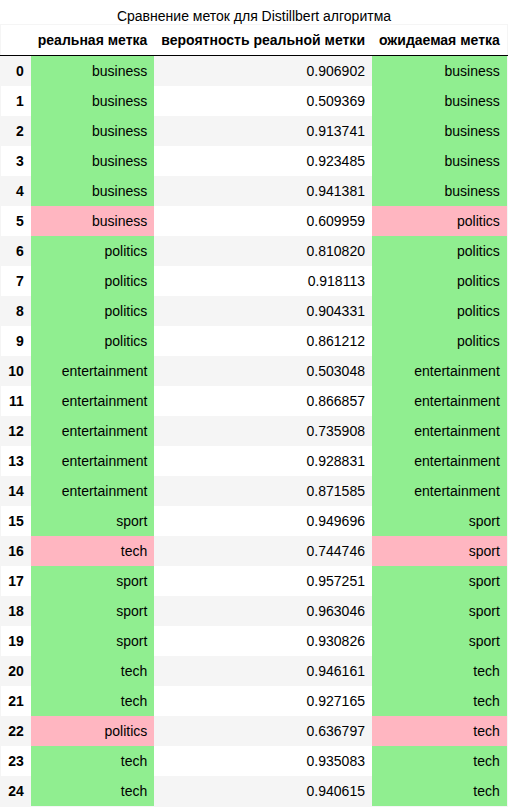

In [30]:
show_actual_expected_labels(distillbert_inference_news, "Сравнение меток для Distillbert алгоритма")

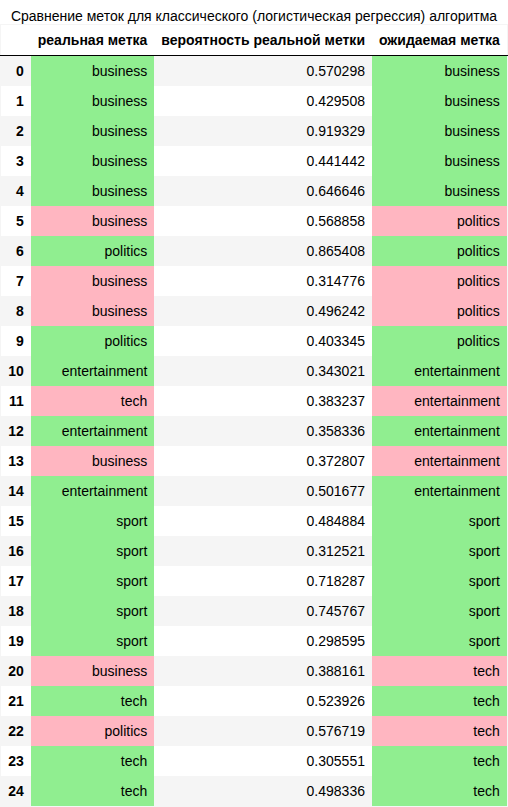

In [31]:
show_actual_expected_labels(classical_inference_news, "Сравнение меток для классического (логистическая регрессия) алгоритма")

In [32]:
inference_texts = fresh_news_df['text'].values
inference_texts_labels = fresh_news_df['label_encoded'].values

In [33]:
inf_pred_logits = distillbert_classifier_pipeline.predict(inference_texts)
inf_preds = torch.argmax(inf_pred_logits, 1)
print("Accuracy на инференсе Distillbert классификатора: {0:6.2f}".format(accuracy_score(inference_texts_labels, inf_preds)))

Accuracy на инференсе Distillbert классификатора:   0.88


In [34]:
probs = classic_classifier_pipeline.predict_proba(inference_texts)
inf_preds = np.argmax(probs, axis=1)
print("Accuracy на инференсе классификатора логистической регрессии: {0:6.2f}".format(accuracy_score(inference_texts_labels, inf_preds)))

Accuracy на инференсе классификатора логистической регрессии:   0.72


Distillbert чаще определяет класс новых данных верно по сравнению с логистической регрессией, кроме того у Distillbert вероятность верного определения превышала 0.8, а у логистической регрессией такая вероятность составляла от 0.3. Таким образом, Distillbert гораздо увереннее классифицирует новые данные.